In [1]:
# Cell 0 — Config & Utils

import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [2]:
# Cell 1 — DB Connection

load_dotenv()

PGUSER=os.getenv("PGUSER")
PGHOST=os.getenv("PGHOST")
PGDATABASE=os.getenv("PGDATABASE")
PGPASSWORD=os.getenv("PGPASSWORD")
PGPORT=os.getenv("PGPORT")


engine = create_engine(f"postgresql+psycopg2://{PGUSER}:{PGPASSWORD}@{PGHOST}:{PGPORT}/{PGDATABASE}")

def q(sql: str) -> pd.DataFrame:
    """Safe SQL runner compatible with SQLAlchemy 2.x."""
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn)

def show(df, n=5):
    display(df.head(n))

def exec_sql(sql: str):
    """Execute DDL/DML SQL (no resultset)."""
    with engine.begin() as conn:
        conn.execute(text(sql))

In [3]:
# Cell 2 — Global constants

SCHEMA       = "public"
RAW_TABLE    = "fm_2024_union_typed"    # Fannie Mae 2024 typed panel
SEQ_L        = 12                       # Sequence length for RNN (months)
SEED         = 42

# Default threshold (90+ DPD = delinquency status >= 3)
DEFAULT_DQ_THRESHOLD = 3

# Ensure output directory exists
os.makedirs("outputs", exist_ok=True)

print(f"Config: SEQ_L={SEQ_L}, DEFAULT_DQ_THRESHOLD={DEFAULT_DQ_THRESHOLD}, SEED={SEED}")


Config: SEQ_L=12, DEFAULT_DQ_THRESHOLD=3, SEED=42


---
# ═══════════════════════════════════════════
# BLOCK 1 — DESCRIPTIVE ANALYTICS (APPENDIX)
# ═══════════════════════════════════════════

Purpose: produce summary tables & figures for the **Appendix** of the article.
- A1. Dataset overview (panel dimensions)
- A2. Per-column profiling (type, fill rate, basic stats)
- A3. Target variable (delinquency & default distribution)
- A4. Key origination features distributions

In [4]:
# 1.0 — Column inventory of raw table

col_meta = q(f"""
SELECT column_name, data_type, ordinal_position
FROM information_schema.columns
WHERE table_schema = '{SCHEMA}'
  AND table_name   = '{RAW_TABLE}'
ORDER BY ordinal_position;
""")

assert not col_meta.empty, f"Table {SCHEMA}.{RAW_TABLE} not found!"

# normalised helpers
col_meta["col"] = col_meta["column_name"].str.strip()
all_columns = col_meta["col"].tolist()
col_types   = dict(zip(col_meta["col"], col_meta["data_type"]))

print(f"Table {SCHEMA}.{RAW_TABLE}: {len(col_meta)} columns")
display(col_meta[["ordinal_position","col","data_type"]])

Table public.fm_2024_union_typed: 110 columns


,ordinal_position,col,data_type
0,1,reference_pool_id,character varying
1,2,loan_identifier,character varying
2,3,monthly_reporting_period,date
3,4,channel,character varying
4,5,seller_name,character varying
...,...,...,...
105,106,alternative_delinquency_resolution,character varying
106,107,alternative_delinquency_resolution_count,integer
107,108,total_deferral_amount,numeric
108,109,payment_deferral_modification_event_indicator,character varying


In [5]:
# 1.1 — A1: Dataset overview (panel dimensions)

# Flexible column resolution
def pick(candidates):
    for c in candidates:
        if c.lower() in [x.lower() for x in all_columns]:
            return next(x for x in all_columns if x.lower()==c.lower())
    return None

loan_col  = pick(["loan_identifier","loan_id"])
mpr_col   = pick(["monthly_reporting_period","month","as_of_month"])
dq_col    = pick(["current_loan_delinquency_status","dq_m","delinquency_status"])
upb_col   = pick(["current_actual_upb","upb","current_upb"])
rate_col  = pick(["current_interest_rate","rate"])
ltv_col   = pick(["original_loan_to_value_ratio_ltv","original_ltv","ltv"])
cltv_col  = pick(["original_combined_loan_to_value_ratio_cltv","cltv"])
dti_col   = pick(["debt_to_income_dti","dti","debt_to_income", "debttoincome_dti"])
fico_col  = pick(["borrower_credit_score_at_origination","fico","credit_score"])
orig_upb  = pick(["original_upb","orig_upb"])
term_col  = pick(["original_loan_term","loan_term"])
chan_col  = pick(["channel"])
state_col = pick(["property_state"])
zb_col    = pick(["zero_balance_code"])
occ_col   = pick(["occupancy_status"])
prop_col  = pick(["property_type"])
purp_col  = pick(["loan_purpose"])
mi_col    = pick(["mortgage_insurance_percentage"])
nbor_col  = pick(["number_of_borrowers"])
age_col   = pick(["loan_age"])
sch_prin  = pick(["scheduled_principal_current","sch_prin"])
tot_prin  = pick(["total_principal_current","tot_prin"])
unsch_prin= pick(["unscheduled_principal_current","unsch_prin"])
mod_col   = pick(["modification_flag"])
defer_col = pick(["total_deferral_amount"])
delin_int = pick(["delinquent_accrued_interest"])
bap_col   = pick(["borrower_assistance_plan"])
adr_col   = pick(["alternative_delinquency_resolution"])
fico_cur  = pick(["borrower_credit_score_current","current_classic_fico"])
lph_col   = pick(["loan_payment_history"])

print("Key columns resolved:")
for name, val in [
    ("loan_id",loan_col),("month",mpr_col),("delinquency",dq_col),
    ("UPB",upb_col),("rate",rate_col),("LTV",ltv_col),("CLTV",cltv_col),
    ("DTI",dti_col),("FICO",fico_col),("orig_UPB",orig_upb),
    ("term",term_col),("channel",chan_col),("state",state_col),
    ("zero_bal",zb_col),("sch_prin",sch_prin),("tot_prin",tot_prin),
    ("unsch_prin",unsch_prin),("mod_flag",mod_col),("deferral",defer_col),
    ("delin_interest",delin_int),("FICO_current",fico_cur),
]:
    status = "✓" if val else "✗ MISSING"
    print(f"  {name:20s} → {str(val):50s} {status}")

Key columns resolved:
  loan_id              → loan_identifier                                    ✓
  month                → monthly_reporting_period                           ✓
  delinquency          → current_loan_delinquency_status                    ✓
  UPB                  → current_actual_upb                                 ✓
  rate                 → current_interest_rate                              ✓
  LTV                  → original_loan_to_value_ratio_ltv                   ✓
  CLTV                 → original_combined_loan_to_value_ratio_cltv         ✓
  DTI                  → debttoincome_dti                                   ✓
  FICO                 → borrower_credit_score_at_origination               ✓
  orig_UPB             → original_upb                                       ✓
  term                 → original_loan_term                                 ✓
  channel              → channel                                            ✓
  state                → property_state   

In [6]:
# 1.2 — Panel summary: N loans, N loan-months, temporal range, avg history length

assert loan_col and mpr_col, "loan_id and month columns must be resolved"

# Month expression
mpr_type = col_types.get(mpr_col, "").lower()
if "date" in mpr_type or "timestamp" in mpr_type:
    month_expr = f"date_trunc('month', \"{mpr_col}\")::date"
else:
    month_expr = f"""CASE
      WHEN regexp_replace(\"{mpr_col}\"::text, '\\D', '', 'g') ~ '^\\d{{5,6}}$'
        THEN to_date(lpad(regexp_replace(\"{mpr_col}\"::text, '\\D', '', 'g'), 6, '0'), 'MMYYYY')
      ELSE (\"{mpr_col}\"::date) END"""

# DQ int expression
if dq_col:
    dq_type = col_types.get(dq_col, "").lower()
    if any(t in dq_type for t in ["int","numeric","double","real"]):
        dq_expr = f'\"{dq_col}\"::int'
    else:
        dq_expr = f"""CASE WHEN \"{dq_col}\"::text ~ '^\\s*\\d+\\s*$'
            THEN trim(\"{dq_col}\"::text)::int ELSE NULL END"""
else:
    dq_expr = "NULL::int"

overview = q(f"""
WITH base AS (
  SELECT
    \"{loan_col}\" AS lid,
    ({month_expr}) AS m
  FROM {SCHEMA}.\"{RAW_TABLE}\"
  WHERE \"{loan_col}\" IS NOT NULL
    AND \"{mpr_col}\" IS NOT NULL
)
SELECT
  COUNT(*)::bigint                        AS n_loan_months,
  COUNT(DISTINCT lid)::bigint             AS n_loans,
  MIN(m)                                  AS min_month,
  MAX(m)                                  AS max_month,
  (MAX(m) - MIN(m))                       AS date_span,
  ROUND(COUNT(*)::numeric / NULLIF(COUNT(DISTINCT lid),0), 1) AS avg_months_per_loan
FROM base;
""")
display(overview.T.rename(columns={0: 'Value'}))
overview.to_csv("outputs/A1_panel_overview.csv", index=False)

,Value
n_loan_months,14130111
n_loans,970976
min_month,2024-01-01
max_month,2025-09-01
date_span,609
avg_months_per_loan,14.6


In [7]:
# 1.3 — A2: Per-column profiling (fill rate, distinct count, min/max/mean for numerics)
#
# We compute everything in SQL to avoid loading the full table into RAM.

profile_parts = []
for c in all_columns:
    dt = col_types.get(c, "")
    # All columns: fill_rate, n_distinct
    # Numeric columns: min, max, mean, stddev
    is_num = any(t in dt.lower() for t in ["int","numeric","double","real","decimal","float"])
    if is_num:
        part = f"""SELECT
            '{c}' AS column_name,
            '{dt}' AS data_type,
            COUNT(*)::bigint AS n_total,
            SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::bigint AS n_filled,
            ROUND(SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::numeric / NULLIF(COUNT(*),0) * 100, 2) AS fill_pct,
            COUNT(DISTINCT \"{c}\")::bigint AS n_distinct,
            ROUND(MIN(\"{c}\"::numeric), 4) AS val_min,
            ROUND(MAX(\"{c}\"::numeric), 4) AS val_max,
            ROUND(AVG(\"{c}\"::numeric), 4) AS val_mean,
            ROUND(STDDEV(\"{c}\"::numeric), 4) AS val_std
        FROM {SCHEMA}.\"{RAW_TABLE}\""""
    else:
        part = f"""SELECT
            '{c}' AS column_name,
            '{dt}' AS data_type,
            COUNT(*)::bigint AS n_total,
            SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::bigint AS n_filled,
            ROUND(SUM(CASE WHEN \"{c}\" IS NOT NULL THEN 1 ELSE 0 END)::numeric / NULLIF(COUNT(*),0) * 100, 2) AS fill_pct,
            COUNT(DISTINCT \"{c}\")::bigint AS n_distinct,
            NULL::numeric AS val_min,
            NULL::numeric AS val_max,
            NULL::numeric AS val_mean,
            NULL::numeric AS val_std
        FROM {SCHEMA}.\"{RAW_TABLE}\""""
    profile_parts.append(part)

# Run in batches to avoid SQL too long
batch_size = 15
profile_dfs = []
for i in range(0, len(profile_parts), batch_size):
    batch = profile_parts[i:i+batch_size]
    sql = " UNION ALL ".join(batch)
    profile_dfs.append(q(sql))

profile = pd.concat(profile_dfs, ignore_index=True)
profile = profile.sort_values("fill_pct", ascending=True).reset_index(drop=True)

print(f"Column profiling: {len(profile)} columns")
display(profile)
profile.to_csv("outputs/A2_column_profile.csv", index=False)

Column profiling: 110 columns


,column_name,data_type,n_total,n_filled,fill_pct,n_distinct,val_min,val_max,val_mean,val_std
0,credit_enhancement_proceeds,numeric,14130111,30,0.0,17,0.0,120285.63,28577.0937,36045.3544
1,interest_bearing_upb,numeric,14130111,0,0.0,0,NaN,NaN,NaN,NaN
2,associated_taxes_for_holding_property,numeric,14130111,30,0.0,20,0.0,10315.08,1717.387,2314.3917
3,asset_recovery_costs,numeric,14130111,30,0.0,4,0.0,2500.0,400.0,821.5838
4,foreclosure_costs,numeric,14130111,30,0.0,29,105.0,11786.33,3427.3993,2788.2733
...,...,...,...,...,...,...,...,...,...,...
105,metropolitan_statistical_area_msa,character varying,14130111,14130111,100.0,409,NaN,NaN,NaN,NaN
106,amortization_type,character varying,14130111,14130111,100.0,1,NaN,NaN,NaN,NaN
107,interest_only_loan_indicator,character varying,14130111,14130111,100.0,1,NaN,NaN,NaN,NaN
108,property_valuation_method,character varying,14130111,14130111,100.0,4,NaN,NaN,NaN,NaN


=== Delinquency status distribution (loan-months) ===


,dq_m,n_obs,pct
0,0,14016151,99.1935
1,1,72610,0.5139
2,2,15892,0.1125
3,3,7610,0.0539
4,4,5021,0.0355
5,5,3741,0.0265
6,6,2607,0.0184
7,7,1869,0.0132
8,8,1428,0.0101
9,9,1019,0.0072



=== Loan-level default rate (ever 3+ DPD) ===


,n_loans,n_defaulted,default_rate_pct
0,970976,6145,0.6329


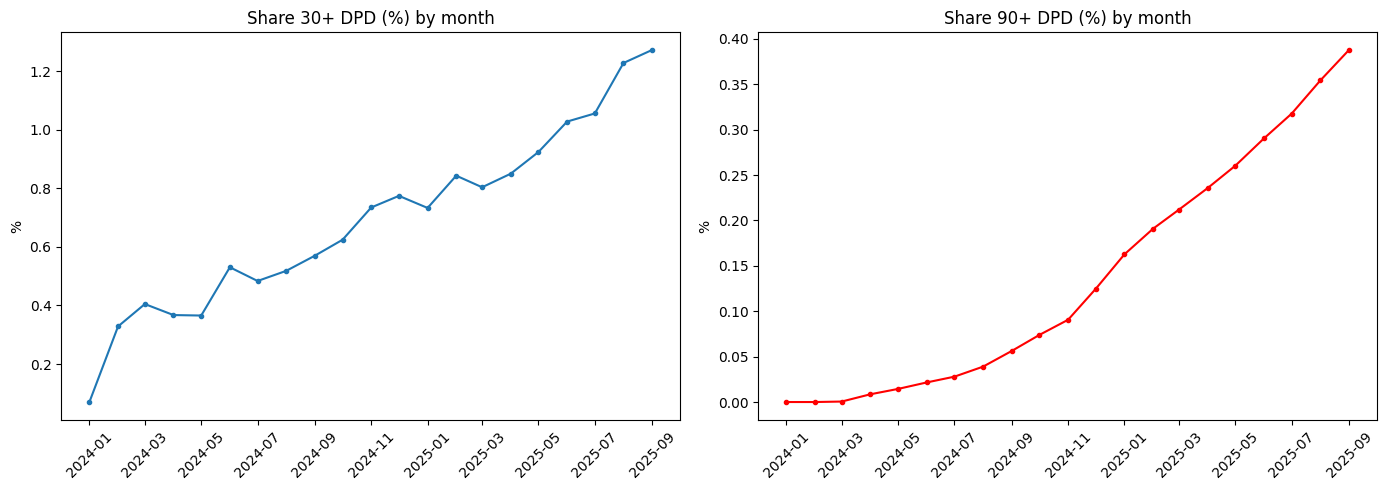

In [8]:
# 1.4 — A3: Delinquency & default distribution

if dq_col:
    # Distribution of delinquency status across loan-months
    dq_dist = q(f"""
    SELECT
      ({dq_expr}) AS dq_m,
      COUNT(*)    AS n_obs,
      ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 4) AS pct
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE ({dq_expr}) IS NOT NULL
    GROUP BY 1 ORDER BY 1;
    """)
    print("=== Delinquency status distribution (loan-months) ===")
    display(dq_dist)

    # Loan-level: ever reached 90+ DPD
    loan_default = q(f"""
    WITH loan_max_dq AS (
      SELECT \"{loan_col}\" AS lid,
             MAX(({dq_expr})) AS max_dq
      FROM {SCHEMA}.\"{RAW_TABLE}\"
      WHERE ({dq_expr}) IS NOT NULL
      GROUP BY 1
    )
    SELECT
      COUNT(*) AS n_loans,
      SUM(CASE WHEN max_dq >= {DEFAULT_DQ_THRESHOLD} THEN 1 ELSE 0 END) AS n_defaulted,
      ROUND(AVG(CASE WHEN max_dq >= {DEFAULT_DQ_THRESHOLD} THEN 1.0 ELSE 0.0 END) * 100, 4) AS default_rate_pct
    FROM loan_max_dq;
    """)
    print(f"\n=== Loan-level default rate (ever {DEFAULT_DQ_THRESHOLD}+ DPD) ===")
    display(loan_default)

    # Monthly delinquency rates (for time-series plot)
    dq_monthly = q(f"""
    SELECT
      ({month_expr}) AS month,
      AVG(CASE WHEN ({dq_expr}) >= 1 THEN 1.0 ELSE 0.0 END) AS share_30plus,
      AVG(CASE WHEN ({dq_expr}) >= 3 THEN 1.0 ELSE 0.0 END) AS share_90plus,
      COUNT(*) AS n_obs
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE ({month_expr}) IS NOT NULL AND ({dq_expr}) IS NOT NULL
    GROUP BY 1 ORDER BY 1;
    """)
    dq_monthly["month"] = pd.to_datetime(dq_monthly["month"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(dq_monthly["month"], dq_monthly["share_30plus"]*100, marker='o', markersize=3)
    axes[0].set_title("Share 30+ DPD (%) by month")
    axes[0].set_ylabel("%")
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(dq_monthly["month"], dq_monthly["share_90plus"]*100, marker='o', markersize=3, color='red')
    axes[1].set_title("Share 90+ DPD (%) by month")
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig("outputs/A3_delinquency_over_time.png", dpi=200)
    plt.show()

    dq_dist.to_csv("outputs/A3_dq_distribution.csv", index=False)
    loan_default.to_csv("outputs/A3_loan_default_rate.csv", index=False)
else:
    print("WARNING: delinquency column not found — skipping A3")

In [9]:
# 1.5 — A4: Distributions of key origination features

key_num_cols = {
    "LTV":          ltv_col,
    "CLTV":         cltv_col,
    "DTI":          dti_col,
    "FICO":         fico_col,
    "Orig_UPB":     orig_upb,
    "Loan_Term":    term_col,
    "Interest_Rate": rate_col,
    "Current_UPB":  upb_col,
}
key_num_cols = {k:v for k,v in key_num_cols.items() if v is not None}

key_cat_cols = {
    "Channel":     chan_col,
    "State":       state_col,
    "Occupancy":   occ_col,
    "Property":    prop_col,
    "Purpose":     purp_col,
}
key_cat_cols = {k:v for k,v in key_cat_cols.items() if v is not None}

# Numeric: percentiles via SQL
pctile_parts = []
for label, col in key_num_cols.items():
    pctile_parts.append(f"""
    SELECT '{label}' AS feature,
      COUNT(\"{col}\")::bigint AS n,
      ROUND(PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p01,
      ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p05,
      ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p25,
      ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS median,
      ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p75,
      ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p95,
      ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY \"{col}\"::numeric)::numeric, 2) AS p99,
      ROUND(AVG(\"{col}\"::numeric), 2) AS mean,
      ROUND(STDDEV(\"{col}\"::numeric), 2) AS std
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE \"{col}\" IS NOT NULL
    """)

if pctile_parts:
    pctile_df = q(" UNION ALL ".join(pctile_parts))
    print("=== Key numeric features: percentile distribution ===")
    display(pctile_df)
    pctile_df.to_csv("outputs/A4_numeric_distributions.csv", index=False)

# Categorical: frequency tables (top values)
for label, col in key_cat_cols.items():
    cat_df = q(f"""
    SELECT \"{col}\"::text AS value,
           COUNT(*) AS n,
           ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 2) AS pct
    FROM {SCHEMA}.\"{RAW_TABLE}\"
    WHERE \"{col}\" IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC LIMIT 15;
    """)
    print(f"\n--- {label} ({col}) ---")
    display(cat_df)

=== Key numeric features: percentile distribution ===


,feature,n,p01,p05,p25,median,p75,p95,p99,mean,std
0,Interest_Rate,14035150,4.99,5.63,6.38,6.63,7.13,7.63,8.13,6.70,0.63
1,Current_UPB,14130111,38282.46,85528.36,185089.49,283778.51,417000.00,681242.10,815000.00,318777.24,182164.99
2,CLTV,14130111,19.00,33.00,64.00,80.00,90.00,97.00,101.00,74.96,19.85
3,Loan_Term,14130111,180.00,240.00,360.00,360.00,360.00,360.00,360.00,349.26,40.94
4,FICO,14106124,639.00,676.00,735.00,770.00,793.00,810.00,817.00,760.00,42.16
5,DTI,14129837,13.00,20.00,31.00,39.00,45.00,49.00,50.00,37.37,9.24
6,LTV,14130111,19.00,33.00,64.00,80.00,90.00,97.00,97.00,74.64,19.69
7,Orig_UPB,14130111,60000.00,98000.00,194000.00,293000.00,428000.00,697000.00,831000.00,329389.74,183164.27



--- Channel (channel) ---


,value,n,pct
0,R,8417185,59.57
1,C,3802523,26.91
2,B,1910403,13.52



--- State (property_state) ---


...

,value,n,pct
0,P,12885357,91.19
1,I,983441,6.96
2,S,261313,1.85



--- Property (property_type) ---


,value,n,pct
0,SF,8183088,57.91
1,PU,4456879,31.54
2,CO,1243379,8.80
3,MH,180842,1.28
4,CP,65923,0.47



--- Purpose (loan_purpose) ---


,value,n,pct
0,P,11329721,80.18
1,C,1821846,12.89
2,R,978544,6.93


---
# ═════════════════════════════════════════
# BLOCK 2 — DATA QUALITY ASSESSMENT
# ═════════════════════════════════════════

Goal: classify **every column** into one of:
- **USE** — directly usable for modeling (fill rate ≥80%, sufficient variance)
- **DERIVE** — needs transformation / imputation / engineering, but contains signal
- **EXCLUDE** — too sparse, constant, post-event, or irrelevant

Criteria:
1. **Fill rate** < 5% → almost certainly EXCLUDE
2. **Fill rate** 5–80% → DERIVE (impute/flag) or EXCLUDE depending on relevance
3. **Near-constant** (n_distinct ≤ 2 on the whole panel, or std ≈ 0) → EXCLUDE
4. **Post-event** columns (foreclosure costs, disposition date, etc.) → EXCLUDE (survivorship / look-ahead bias)
5. **Identifier / admin** columns (seller_name, servicer_name, reference_pool_id) → EXCLUDE

In [10]:
# 2.1 — Automated quality classification

# Post-event columns (known from Fannie Mae glossary): these are populated AFTER
# a credit event, disposition, or zero-balance — using them would be look-ahead bias.
POST_EVENT_COLS = {
    "zero_balance_effective_date", "upb_at_the_time_of_removal",
    "repurchase_date", "foreclosure_date", "disposition_date",
    "foreclosure_costs", "property_preservation_and_repair_costs",
    "asset_recovery_costs", "miscellaneous_holding_expenses_and_credits",
    "associated_taxes_for_holding_property", "net_sales_proceeds",
    "credit_enhancement_proceeds", "repurchase_make_whole_proceeds",
    "other_foreclosure_proceeds", "principal_forgiveness_amount",
    "foreclosure_principal_write_off_amount",
    "current_period_modification_loss_amount", "cumulative_modification_loss_amount",
    "current_period_credit_event_net_gain_or_loss",
    "cumulative_credit_event_net_gain_or_loss",
    "original_list_start_date", "original_list_price",
    "current_list_start_date", "current_list_price",
    "repurchase_make_whole_proceeds_flag",
    "zero_balance_code_change_date",
    "loan_holdback_indicator", "loan_holdback_effective_date",
}

# Admin / identifier columns
ADMIN_COLS = {
    "reference_pool_id", "loan_identifier", "seller_name", "servicer_name",
    "master_servicer", "deal_name",
    "metropolitan_statistical_area_msa_or_metropolitan_statistical_division_area_msda",
    "zip_code_short", "monthly_reporting_period",
    "loan_payment_history",  # coded string, needs special parsing
}

# ARM-specific columns (irrelevant for FRM-dominant portfolio)
ARM_COLS = {
    "arm_initial_fixed_rate_period_5_yr_indicator", "arm_product_type",
    "initial_fixed_rate_period", "interest_rate_adjustment_frequency",
    "next_interest_rate_adjustment_date", "next_payment_change_date",
    "index", "arm_cap_structure", "initial_interest_rate_cap_up_percent",
    "periodic_interest_rate_cap_up_percent", "lifetime_interest_rate_cap_up_percent",
    "mortgage_margin", "arm_balloon_indicator", "arm_plan_number",
}

def classify_column(row):
    cname = row["column_name"].lower().strip()
    fill  = row["fill_pct"] if pd.notna(row["fill_pct"]) else 0
    ndist = row["n_distinct"] if pd.notna(row["n_distinct"]) else 0

    # 1) Admin / ID
    if cname in ADMIN_COLS or any(cname.startswith(a) for a in ADMIN_COLS):
        return "EXCLUDE", "identifier / admin"
    # 2) Post-event
    if cname in POST_EVENT_COLS or any(cname.startswith(p) for p in POST_EVENT_COLS):
        return "EXCLUDE", "post-event (look-ahead bias)"
    # 3) ARM-specific
    if cname in ARM_COLS or any(cname.startswith(a) for a in ARM_COLS):
        return "EXCLUDE", "ARM-specific (FRM-dominant sample)"
    # 4) Fill rate
    if fill < 5:
        return "EXCLUDE", f"very sparse (fill={fill:.1f}%)"
    if fill < 50:
        return "DERIVE", f"moderate fill ({fill:.1f}%); needs imputation/flag"
    # 5) Near-constant
    if ndist <= 1:
        return "EXCLUDE", "constant (no variance)"
    # 6) Usable
    if fill >= 80:
        return "USE", f"good quality (fill={fill:.1f}%, distinct={ndist})"
    else:
        return "DERIVE", f"fill={fill:.1f}%, may need imputation"

quality = profile.copy()
quality[["decision","reason"]] = quality.apply(classify_column, axis=1, result_type="expand")

print("=== Quality classification summary ===")
print(quality["decision"].value_counts())
print()

for dec in ["USE","DERIVE","EXCLUDE"]:
    sub = quality[quality["decision"]==dec][["column_name","data_type","fill_pct","n_distinct","reason"]]
    print(f"\n--- {dec} ({len(sub)} columns) ---")
    display(sub.reset_index(drop=True))

quality.to_csv("outputs/B1_column_quality_classification.csv", index=False)

=== Quality classification summary ===
decision
EXCLUDE    73
USE        34
DERIVE      3
Name: count, dtype: int64


--- USE (34 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,total_principal_current,numeric,93.13,581063,"good quality (fill=93.1%, distinct=581063)"
1,remaining_months_to_maturity,integer,99.32,360,"good quality (fill=99.3%, distinct=360)"
2,servicing_activity_indicator,character varying,99.33,2,"good quality (fill=99.3%, distinct=2)"
3,remaining_months_to_legal_maturity,integer,99.33,335,"good quality (fill=99.3%, distinct=335)"
4,maturity_date,date,99.33,300,"good quality (fill=99.3%, distinct=300)"
5,modification_flag,character varying,99.33,2,"good quality (fill=99.3%, distinct=2)"
6,loan_age,integer,99.33,38,"good quality (fill=99.3%, distinct=38)"
7,current_interest_rate,numeric,99.33,2292,"good quality (fill=99.3%, distinct=2292)"
8,borrower_credit_score_at_origination,integer,99.83,322,"good quality (fill=99.8%, distinct=322)"
9,borrower_assistance_plan,character varying,100.00,5,"good quality (fill=100.0%, distinct=5)"



--- DERIVE (3 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,mortgage_insurance_percentage,numeric,36.57,21,moderate fill (36.6%); needs imputation/flag
1,mortgage_insurance_type,character varying,36.57,2,moderate fill (36.6%); needs imputation/flag
2,coborrower_credit_score_at_origination,integer,44.42,310,moderate fill (44.4%); needs imputation/flag



--- EXCLUDE (73 columns) ---


,column_name,data_type,fill_pct,n_distinct,reason
0,credit_enhancement_proceeds,numeric,0.0,17,post-event (look-ahead bias)
1,interest_bearing_upb,numeric,0.0,0,very sparse (fill=0.0%)
2,associated_taxes_for_holding_property,numeric,0.0,20,post-event (look-ahead bias)
3,asset_recovery_costs,numeric,0.0,4,post-event (look-ahead bias)
4,foreclosure_costs,numeric,0.0,29,post-event (look-ahead bias)
...,...,...,...,...,...
68,zip_code_short,character varying,100.0,888,identifier / admin
69,prepayment_penalty_indicator,character varying,100.0,1,constant (no variance)
70,amortization_type,character varying,100.0,1,constant (no variance)
71,interest_only_loan_indicator,character varying,100.0,1,constant (no variance)


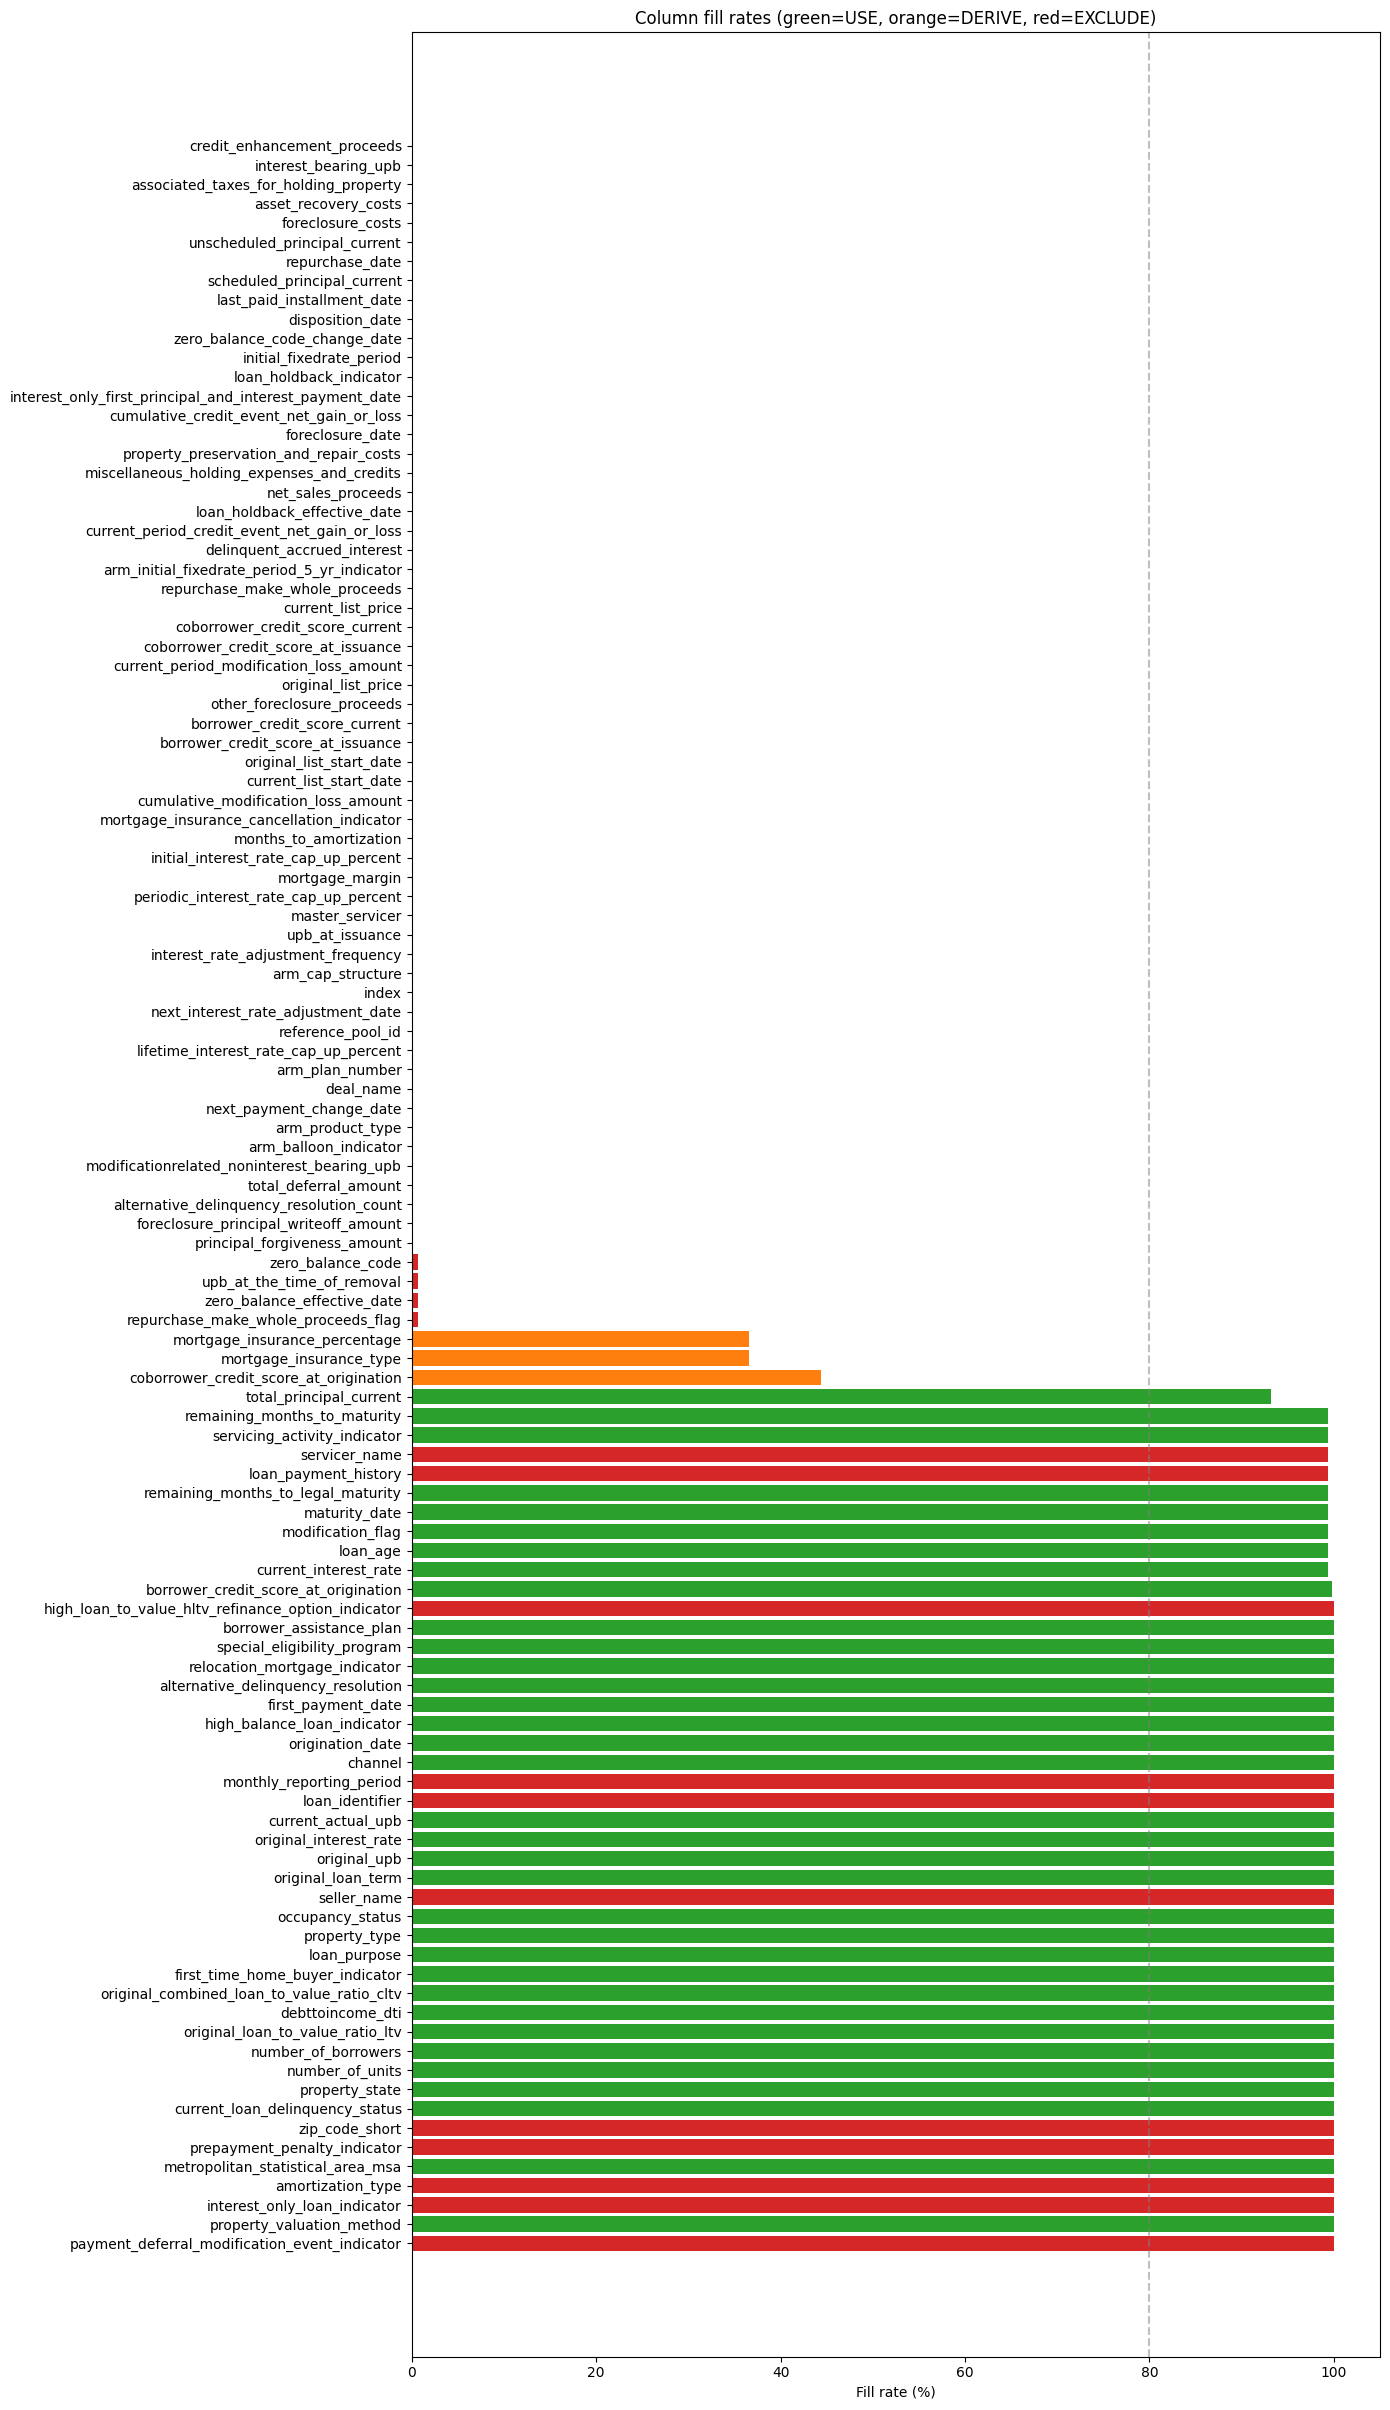

In [11]:
# 2.2 — Visual: fill rates across all columns (sorted)

fig, ax = plt.subplots(figsize=(14, max(6, len(quality)*0.22)))
colors = quality["decision"].map({"USE":"#2ca02c", "DERIVE":"#ff7f0e", "EXCLUDE":"#d62728"})
ax.barh(quality["column_name"], quality["fill_pct"], color=colors)
ax.set_xlabel("Fill rate (%)")
ax.set_title("Column fill rates (green=USE, orange=DERIVE, red=EXCLUDE)")
ax.axvline(80, color="gray", linestyle="--", alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/B2_fill_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# 2.3 — Summary: columns selected for the study
#
# This produces the definitive feature list, which will map into the
# financial-logistics components (Nodes / Arcs / Buffers / Disruptions).

usable = quality[quality["decision"].isin(["USE","DERIVE"])]["column_name"].tolist()
print(f"Columns available for modeling: {len(usable)}")
for c in usable:
    print(f"  • {c}  ({quality.loc[quality['column_name']==c, 'reason'].iloc[0]})")

Columns available for modeling: 37
  • mortgage_insurance_percentage  (moderate fill (36.6%); needs imputation/flag)
  • mortgage_insurance_type  (moderate fill (36.6%); needs imputation/flag)
  • coborrower_credit_score_at_origination  (moderate fill (44.4%); needs imputation/flag)
  • total_principal_current  (good quality (fill=93.1%, distinct=581063))
  • remaining_months_to_maturity  (good quality (fill=99.3%, distinct=360))
  • servicing_activity_indicator  (good quality (fill=99.3%, distinct=2))
  • remaining_months_to_legal_maturity  (good quality (fill=99.3%, distinct=335))
  • maturity_date  (good quality (fill=99.3%, distinct=300))
  • modification_flag  (good quality (fill=99.3%, distinct=2))
  • loan_age  (good quality (fill=99.3%, distinct=38))
  • current_interest_rate  (good quality (fill=99.3%, distinct=2292))
  • borrower_credit_score_at_origination  (good quality (fill=99.8%, distinct=322))
  • borrower_assistance_plan  (good quality (fill=100.0%, distinct=5))
  • sp

---
# ════════════════════════════════════════════════════
# BLOCK 3 — EMPIRICAL PART (METHODOLOGY-ALIGNED)
# ════════════════════════════════════════════════════

Strict pipeline following the article's **MODEL ARCHITECTURE** (Section 4) and **EXPERIMENTAL SETUP** (Section 5):

1. **3.1** — Feature engineering & Financial-Logistics mapping
2. **3.2** — Panel construction (SQL views)
3. **3.3** — Data splitting (temporal, no leakage)
4. **3.4** — Baseline models (Logistic Regression, GBDT, Cox PH, Static NN)
5. **3.5** — RNN Hazard model (GRU/LSTM)
6. **3.6** — Evaluation metrics (ROC-AUC, PR-AUC, Precision@k, Brier, Time-dep AUC)
7. **3.7** — Ablation analysis (group masking by component)
8. **3.8** — Export results for article

In [13]:
# 3.1 — Feature-to-Component Mapping (Table 1 of the article)
#
# MODIFIED: explicit mapping with 25 features matching the code pipeline.
# Formal mapping M: X_j → C_k ∈ {Node, Arc, Buffer, Disruption}
# following Section III.G / III.H of the paper.

# ── MAPPING DEFINITION ──
# Format: (resolved_column_or_alias, component, functional_role, rationale)

FEATURE_MAP_RAW = [
    # ═══ NODES (structural state of the borrower) ═══
    (ltv_col,    "Node", "Structural leverage",
     "Original debt-to-asset configuration"),
    (cltv_col,   "Node", "Combined leverage",
     "Total leverage including subordinate liens"),
    (dti_col,    "Node", "Structural debt burden",
     "Debt load as share of income at origination"),
    (fico_col,   "Node", "Credit profile",
     "Static creditworthiness proxy"),
    (orig_upb,   "Node", "Debt structure",
     "Original obligation size"),
    (term_col,   "Node", "Contract structure",
     "Loan maturity; defines repayment schedule"),
    (rate_col,   "Node", "Cost of debt",
     "Current interest rate; quasi-static for FRM"),

    # ═══ ARCS (cash flow dynamics) ═══
    (upb_col,    "Arc", "Outstanding balance",
     "Current debt level; changes reflect principal flows"),
    (sch_prin,   "Arc", "Scheduled principal flow",
     "Contractual principal amortization intensity"),
    (tot_prin,   "Arc", "Total principal flow",
     "Realized principal payment (scheduled + unscheduled)"),
    (unsch_prin, "Arc", "Unscheduled principal flow",
     "Prepayment component; excess cash flow intensity"),

    # ═══ BUFFERS (financial stability reserves) ═══
    ("amort_buffer",  "Buffer", "Amortization buffer",
     "Ratio of scheduled principal to UPB — repayment pace"),
    (defer_col,       "Buffer", "Deferral capacity",
     "Deferred amount = implicit liquidity reserve"),
    (mi_col,          "Buffer", "Insurance reserve",
     "MI percentage provides loss absorption capacity"),
    (fico_cur,        "Buffer", "Current credit health",
     "Updated FICO; reflects borrower's current resilience"),

    # ═══ DISRUPTIONS (instability / shocks) ═══
    (dq_col,     "Disruption", "Payment breakdown",
     "Delinquency status = direct disruption measure"),
    ("dq_change_1m",  "Disruption", "Flow degradation speed",
     "Δ delinquency month-over-month"),
    ("roll_worse_1m", "Disruption", "Roll-forward indicator",
     "Binary: delinquency worsened"),
    ("cure_1m",       "Disruption", "Self-correction signal",
     "Binary: borrower cured (improvement)"),
    ("dq_mean_3m",    "Disruption", "Sustained instability",
     "3-month rolling mean of delinquency"),
    ("dq_std_3m",     "Disruption", "Instability volatility",
     "3-month volatility of delinquency status"),
    (mod_col,         "Disruption", "Modification signal",
     "Loan modified = prior stress event"),
    (delin_int,       "Disruption", "Accrued disruption cost",
     "Delinquent interest = cumulative disruption effect"),
]

# Filter out None (missing columns)
FEATURE_MAP = [(c, comp, role, rat) for c, comp, role, rat in FEATURE_MAP_RAW if c is not None]
print(f"Feature map: {len(FEATURE_MAP)} features")
for comp in ["Node", "Arc", "Buffer", "Disruption"]:
    subset = [c for c, co, r, ra in FEATURE_MAP if co == comp]
    print(f"  {comp:12s}: {len(subset)} — {subset}")


Feature map: 23 features
  Node        : 7 — ['original_loan_to_value_ratio_ltv', 'original_combined_loan_to_value_ratio_cltv', 'debttoincome_dti', 'borrower_credit_score_at_origination', 'original_upb', 'original_loan_term', 'current_interest_rate']
  Arc         : 4 — ['current_actual_upb', 'scheduled_principal_current', 'total_principal_current', 'unscheduled_principal_current']
  Buffer      : 4 — ['amort_buffer', 'total_deferral_amount', 'mortgage_insurance_percentage', 'borrower_credit_score_current']
  Disruption  : 8 — ['current_loan_delinquency_status', 'dq_change_1m', 'roll_worse_1m', 'cure_1m', 'dq_mean_3m', 'dq_std_3m', 'modification_flag', 'delinquent_accrued_interest']


In [14]:
# 3.2 — Panel construction: materialized tables + derived features
#
# MODIFIED: single-pass materialization instead of VIEW chains.
# The old approach (VIEW→VIEW→VIEW→MATVIEW) caused cascading full-scans.
# New approach: TABLE fm_panel_base → TABLE fm_panel_features (all derived
# columns computed in one pass) → JOIN labels.

import time as _time
_t0 = _time.time()

def qc(c):
    return f'"{c}"' if c else 'NULL'

# ─── Cleanup ───
for ddl in [
    "DROP TABLE IF EXISTS public.fm_rnn_ready CASCADE",
    "DROP TABLE IF EXISTS public.fm_labels CASCADE",
    "DROP TABLE IF EXISTS public.fm_panel_base CASCADE",
]:
    exec_sql(ddl)

# ─── 1) fm_panel_base — cleaned, typed panel ───
exec_sql(f"""
CREATE TABLE public.fm_panel_base AS
SELECT
  {qc(loan_col)}::text                            AS loan_id,
  ({month_expr})                                   AS month,
  ({dq_expr})                                      AS dq_m,
  COALESCE({qc(rate_col)}::numeric, 0)             AS rate,
  COALESCE({qc(ltv_col)}::numeric, 0)              AS ltv,
  COALESCE({qc(cltv_col)}::numeric, 0)             AS cltv,
  COALESCE({qc(dti_col)}::numeric, 0)              AS dti,
  COALESCE({qc(fico_col)}::numeric, 0)             AS fico_orig,
  COALESCE({qc(fico_cur) if fico_cur else 'NULL'}::numeric, 0) AS fico_cur,
  COALESCE({qc(orig_upb)}::numeric, 0)             AS orig_upb,
  COALESCE({qc(upb_col)}::numeric, 0)              AS current_upb,
  COALESCE({qc(term_col)}::numeric, 0)             AS loan_term,
  COALESCE({qc(sch_prin) if sch_prin else 'NULL'}::numeric, 0)  AS sch_prin,
  COALESCE({qc(tot_prin) if tot_prin else 'NULL'}::numeric, 0)  AS tot_prin,
  COALESCE({qc(unsch_prin) if unsch_prin else 'NULL'}::numeric, 0) AS unsch_prin,
  COALESCE({qc(delin_int) if delin_int else 'NULL'}::numeric, 0)  AS delin_int,
  COALESCE({qc(defer_col) if defer_col else 'NULL'}::numeric, 0)  AS deferral_amt,
  CASE WHEN COALESCE({qc(defer_col) if defer_col else 'NULL'}::numeric, 0) > 0
       THEN 1 ELSE 0 END AS deferral_flag,
  CASE WHEN UPPER(COALESCE({qc(mod_col) if mod_col else "'N'"}::text, 'N')) = 'Y'
       THEN 1 ELSE 0 END AS mod_flag,
  COALESCE({qc(mi_col) if mi_col else 'NULL'}::numeric, 0) AS mi_pct,
  {qc(zb_col) if zb_col else 'NULL'}::text        AS zero_balance_code
FROM {SCHEMA}."{RAW_TABLE}"
WHERE {qc(loan_col)} IS NOT NULL
  AND ({month_expr}) IS NOT NULL;
""")

exec_sql("CREATE INDEX ix_pb_lid_month ON public.fm_panel_base (loan_id, month);")
exec_sql("CREATE INDEX ix_pb_lid       ON public.fm_panel_base (loan_id);")
exec_sql("ANALYZE public.fm_panel_base;")

n_base = q("SELECT COUNT(*) AS n FROM public.fm_panel_base;").iloc[0,0]
print(f"✓ fm_panel_base: {int(n_base):,} rows  ({_time.time()-_t0:.1f}s)")

# ─── 2) fm_labels — loan-level default info ───
_t1 = _time.time()
exec_sql(f"""
CREATE TABLE public.fm_labels AS
WITH first_default AS (
  SELECT loan_id, MIN(month) AS default_month
  FROM public.fm_panel_base
  WHERE dq_m >= {DEFAULT_DQ_THRESHOLD}
  GROUP BY loan_id
)
SELECT
  b.loan_id,
  d.default_month,
  CASE WHEN d.default_month IS NOT NULL THEN 0 ELSE 1 END AS censored
FROM (SELECT DISTINCT loan_id FROM public.fm_panel_base) b
LEFT JOIN first_default d USING (loan_id);
""")
exec_sql("CREATE UNIQUE INDEX ix_lbl_lid ON public.fm_labels (loan_id);")
exec_sql("ANALYZE public.fm_labels;")

lbl = q("SELECT COUNT(*) AS n, SUM(CASE WHEN censored=0 THEN 1 ELSE 0 END) AS n_def FROM public.fm_labels;")
n_loans = int(lbl.iloc[0]["n"]); n_def = int(lbl.iloc[0]["n_def"])
print(f"✓ fm_labels: {n_loans:,} loans, {n_def:,} defaulted ({n_def/n_loans*100:.4f}%)  ({_time.time()-_t1:.1f}s)")


✓ fm_panel_base: 14,130,111 rows  (148.9s)
✓ fm_labels: 970,976 loans, 6,145 defaulted (0.6329%)  (1018.8s)


In [15]:
# 3.2b — Build final analysis table with ALL derived features in one pass
#
# NEW: single SQL query computes all window functions + labels + time index.
# Replaces the old VIEW→VIEW→VIEW chain that caused full-scan cascades.

_t2 = _time.time()

exec_sql("""
CREATE TABLE public.fm_rnn_ready AS
WITH features AS (
  SELECT
    p.loan_id, p.month, p.dq_m,
    -- Derived disruption features
    p.dq_m - LAG(p.dq_m, 1) OVER w                  AS dq_change_1m,
    CASE WHEN p.dq_m > COALESCE(LAG(p.dq_m, 1) OVER w, 0) THEN 1 ELSE 0 END AS roll_worse_1m,
    CASE WHEN p.dq_m < COALESCE(LAG(p.dq_m, 1) OVER w, 0) THEN 1 ELSE 0 END AS cure_1m,
    AVG(p.dq_m)    OVER (PARTITION BY p.loan_id ORDER BY p.month
                         ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS dq_mean_3m,
    STDDEV(p.dq_m) OVER (PARTITION BY p.loan_id ORDER BY p.month
                         ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS dq_std_3m,
    -- Derived arc feature
    p.current_upb - LAG(p.current_upb, 1) OVER w     AS upb_change_1m,
    -- Derived buffer feature
    CASE WHEN p.current_upb > 0
         THEN p.sch_prin / p.current_upb ELSE 0 END  AS amort_buffer,
    -- Pass-through features
    p.rate, p.ltv, p.cltv, p.dti, p.fico_orig, p.fico_cur,
    p.orig_upb, p.current_upb, p.loan_term,
    p.sch_prin, p.tot_prin, p.unsch_prin, p.delin_int,
    p.deferral_amt, p.deferral_flag, p.mod_flag, p.mi_pct,
    -- Labels
    l.default_month,
    CASE WHEN l.default_month IS NOT NULL AND p.month = l.default_month
         THEN 1 ELSE 0 END AS event,
    -- Time index
    (ROW_NUMBER() OVER (PARTITION BY p.loan_id ORDER BY p.month) - 1) AS t,
    COUNT(*) OVER (PARTITION BY p.loan_id) AS t_cnt
  FROM public.fm_panel_base p
  JOIN public.fm_labels l USING (loan_id)
  WINDOW w AS (PARTITION BY p.loan_id ORDER BY p.month)
)
SELECT * FROM features;
""")

exec_sql("CREATE INDEX ix_rnn_lid_month ON public.fm_rnn_ready (loan_id, month);")
exec_sql("CREATE INDEX ix_rnn_lid       ON public.fm_rnn_ready (loan_id);")
exec_sql("CREATE INDEX ix_rnn_tcnt      ON public.fm_rnn_ready (t_cnt);")
exec_sql("ANALYZE public.fm_rnn_ready;")

stats = q("""
  SELECT COUNT(*) AS n_rows,
         COUNT(DISTINCT loan_id) AS n_loans,
         SUM(event) AS n_events,
         ROUND(AVG(event::numeric)*100, 5) AS event_rate_pct
  FROM public.fm_rnn_ready;
""")
display(stats)
print(f"\n✓ fm_rnn_ready table built ({_time.time()-_t2:.1f}s)")
print(f"  Total pipeline time: {_time.time()-_t0:.1f}s")


,n_rows,n_loans,n_events,event_rate_pct
0,14130111,970976,6145,0.04349



✓ fm_rnn_ready table built (143.6s)
  Total pipeline time: 1311.4s


In [16]:
# 3.2c — Sanity checks on raw SQL table
#
# Verify that the columns we need exist and contain real data.
# NOTE: derived features (payment_ratio, etc.) are computed in cell 19.
#       Here we only check the raw columns from the SQL pipeline.

src_cols = q("""
  SELECT column_name FROM information_schema.columns
  WHERE table_schema='public' AND table_name='fm_rnn_ready';
""")["column_name"].tolist()

print("Columns in fm_rnn_ready:", sorted(src_cols))

# Raw features we need from SQL
raw_needed = [
    "rate", "ltv", "cltv", "dti", "fico_orig", "orig_upb", "loan_term",
    "current_upb", "tot_prin", "upb_change_1m",
    "mi_pct", "mod_flag", "dq_m",  # dq_m needed for target construction
]

missing = [c for c in raw_needed if c not in src_cols]
present = [c for c in raw_needed if c in src_cols]

if missing:
    print(f"\n⚠ MISSING: {missing}")
else:
    print(f"\n✓ All {len(raw_needed)} required raw columns present")

# Check non-zero rates for key columns
nz_check = q(f"""
  SELECT
    {', '.join(f'ROUND(AVG(CASE WHEN "{c}" != 0 THEN 1.0 ELSE 0.0 END)::numeric, 4) AS "{c}"' for c in present)}
  FROM public.fm_rnn_ready
  LIMIT 500000;
""")
print("\nNon-zero rates:")
for c in present:
    rate = float(nz_check[c].iloc[0])
    status = "✓" if rate > 0.01 else "⚠ LOW"
    print(f"  {status} {c}: {rate*100:.1f}%")

# Sample
sample = q(f"""
  SELECT loan_id, month, t, {', '.join(f'"{c}"' for c in present[:8])}
  FROM public.fm_rnn_ready WHERE t_cnt >= {SEQ_L}
  ORDER BY loan_id, month LIMIT 5;
""")
print("\nSample:")
display(sample)

assert len(missing) == 0, f"Missing columns: {missing}"
print("\n✓ Sanity checks passed")

Columns in fm_rnn_ready: ['amort_buffer', 'cltv', 'cure_1m', 'current_upb', 'default_month', 'deferral_amt', 'deferral_flag', 'delin_int', 'dq_change_1m', 'dq_m', 'dq_mean_3m', 'dq_std_3m', 'dti', 'event', 'fico_cur', 'fico_orig', 'loan_id', 'loan_term', 'ltv', 'mi_pct', 'mod_flag', 'month', 'orig_upb', 'rate', 'roll_worse_1m', 'sch_prin', 't', 't_cnt', 'tot_prin', 'unsch_prin', 'upb_change_1m']

✓ All 13 required raw columns present

Non-zero rates:
  ✓ rate: 99.3%
  ✓ ltv: 100.0%
  ✓ cltv: 100.0%
  ✓ dti: 100.0%
  ✓ fico_orig: 99.8%
  ✓ orig_upb: 100.0%
  ✓ loan_term: 100.0%
  ✓ current_upb: 99.3%
  ✓ tot_prin: 87.2%
  ✓ upb_change_1m: 65.5%
  ✓ mi_pct: 36.6%
  ⚠ LOW mod_flag: 0.0%
  ⚠ LOW dq_m: 0.8%

Sample:


,loan_id,month,t,rate,ltv,cltv,dti,fico_orig,orig_upb,loan_term,current_upb
0,000137581448,2024-01-01,0,6.99,70.0,70.0,49.0,754.0,450000.0,360.0,450000.0
1,000137581448,2024-02-01,1,6.99,70.0,70.0,49.0,754.0,450000.0,360.0,450000.0
2,000137581448,2024-03-01,2,6.99,70.0,70.0,49.0,754.0,450000.0,360.0,449000.0
3,000137581448,2024-04-01,3,6.99,70.0,70.0,49.0,754.0,450000.0,360.0,449000.0
4,000137581448,2024-05-01,4,6.99,70.0,70.0,49.0,754.0,450000.0,360.0,449000.0



✓ Sanity checks passed


In [17]:
# 3.3 — Load panel data, create derived features, define groups
#
# STRATEGY:
#   1. Load raw features from DB (only non-zero ones)
#   2. Compute derived features in Python (payment ratios, trends)
#   3. Map to 4 financial-logistics components for GNN
#
# Delinquency status (dq_m) and its derivatives are EXCLUDED from inputs
# to prevent leakage. dq_m is loaded for target construction only.
#
# Zero-data features removed: sch_prin, unsch_prin, amort_buffer,
# fico_cur, delin_int, deferral_amt/flag (all <0.04% non-zero in data)

import gc, time as _time
_t0 = _time.time()

# ── Raw features to load from DB ──
raw_features = [
    "rate", "ltv", "cltv", "dti", "fico_orig", "orig_upb", "loan_term",  # nodes
    "current_upb", "tot_prin", "upb_change_1m",                           # arcs
    "mi_pct",                                                              # buffer
    "mod_flag",                                                            # disruption
]

select_cols = ', '.join(f'COALESCE("{c}", 0)::float4 AS "{c}"' for c in raw_features)

sql = f"""
SELECT loan_id, month, event, default_month, t, dq_m,
       {select_cols}
FROM public.fm_rnn_ready
WHERE t_cnt >= {SEQ_L}
ORDER BY loan_id, month;
"""

rnn_df = q(sql)
print(f"Query time: {_time.time()-_t0:.1f}s")

# Type casting
rnn_df["month"] = pd.to_datetime(rnn_df["month"], errors="coerce")
rnn_df["default_month"] = pd.to_datetime(rnn_df["default_month"], errors="coerce")
for c in ["event", "t", "dq_m"] + raw_features:
    rnn_df[c] = pd.to_numeric(rnn_df[c], errors="coerce").fillna(0)
rnn_df = rnn_df.dropna(subset=["month"])
for c in raw_features:
    rnn_df[c] = rnn_df[c].astype("float32")
rnn_df["event"] = rnn_df["event"].astype("int8")
rnn_df["t"]     = rnn_df["t"].astype("int16")

print(f"Loaded: {len(rnn_df):,} rows, {rnn_df['loan_id'].nunique():,} loans")

# ═══════════════════════════════════════════
# Compute derived features (temporal, within-loan)
# ═══════════════════════════════════════════
print("\nComputing derived features...")
_td = _time.time()

# Sort for correct groupby operations
rnn_df = rnn_df.sort_values(["loan_id", "month"]).reset_index(drop=True)
g = rnn_df.groupby("loan_id", sort=False)

# ── ARC-derived: payment dynamics ──
# Payment intensity: what fraction of balance was paid this month
rnn_df["payment_ratio"] = np.where(
    rnn_df["current_upb"] > 0,
    rnn_df["tot_prin"] / rnn_df["current_upb"],
    0.0
).astype("float32")

# Relative UPB change (normalized by balance)
rnn_df["upb_pct_change"] = np.where(
    rnn_df["current_upb"] > 0,
    rnn_df["upb_change_1m"] / rnn_df["current_upb"],
    0.0
).astype("float32")

# ── BUFFER-derived: financial resilience indicators ──
# Paydown progress: how much of the original loan has been repaid
rnn_df["paydown_progress"] = np.where(
    rnn_df["orig_upb"] > 0,
    (rnn_df["orig_upb"] - rnn_df["current_upb"]) / rnn_df["orig_upb"],
    0.0
).astype("float32")

# Monthly payment estimate (from rate and term, approximation)
# monthly_rate = rate / 100 / 12
# expected_payment ≈ UPB * monthly_rate / (1 - (1+monthly_rate)^-remaining_term)
# Simplified: just use rate * UPB / 1200 as proxy
rnn_df["debt_service_ratio"] = np.where(
    rnn_df["current_upb"] > 0,
    (rnn_df["rate"] / 1200) * rnn_df["current_upb"] / np.maximum(rnn_df["orig_upb"], 1),
    0.0
).astype("float32")

# ── DISRUPTION-derived: payment behavior anomalies ──
# Payment shortfall: is tot_prin lower than expected?
# Expected ~ recent average. Compute rolling mean of tot_prin (3m)
rnn_df["tot_prin_ma3"] = g["tot_prin"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
).astype("float32")

# Payment volatility (3-month std of tot_prin)
rnn_df["payment_vol_3m"] = g["tot_prin"].transform(
    lambda x: x.rolling(3, min_periods=1).std().fillna(0)
).astype("float32")

# UPB acceleration: is UPB change getting worse? (2nd derivative)
rnn_df["upb_accel"] = g["upb_change_1m"].transform(
    lambda x: x.diff().fillna(0)
).astype("float32")

print(f"Derived features computed ({_time.time()-_td:.1f}s)")

# ═══════════════════════════════════════════
# Define feature groups for GNN
# ═══════════════════════════════════════════

feat_nodes = ["rate", "ltv", "cltv", "dti", "fico_orig", "orig_upb", "loan_term"]

feat_arcs  = ["current_upb", "tot_prin", "upb_change_1m",
              "payment_ratio", "upb_pct_change"]

feat_bufs  = ["mi_pct", "paydown_progress", "debt_service_ratio"]

feat_disr  = ["mod_flag", "tot_prin_ma3", "payment_vol_3m", "upb_accel"]

feature_cols = feat_nodes + feat_arcs + feat_bufs + feat_disr

# Groups for ablation
group_indices = {
    "Nodes (V)":       [feature_cols.index(c) for c in feat_nodes],
    "Arcs (F)":        [feature_cols.index(c) for c in feat_arcs],
    "Buffers (B)":     [feature_cols.index(c) for c in feat_bufs],
    "Disruptions (D)": [feature_cols.index(c) for c in feat_disr],
}

node_dims = [len(feat_nodes), len(feat_arcs), len(feat_bufs), len(feat_disr)]

print(f"\nTotal features: {len(feature_cols)}")
print(f"Node dimensions for GNN: {node_dims}")
for g_name, idx in group_indices.items():
    print(f"  {g_name}: {len(idx)} — {[feature_cols[i] for i in idx]}")

# ── Validate ──
n_rows = len(rnn_df)
n_loans = rnn_df["loan_id"].nunique()
n_events = int(rnn_df["event"].sum())
mem_mb = rnn_df.memory_usage(deep=True).sum() / 1e6

print(f"\nDataset: {n_rows:,} rows, {n_loans:,} loans, {n_events:,} events")
print(f"Memory: {mem_mb:.0f} MB")

print("\nFeature non-zero rates:")
for c in feature_cols:
    nz = (rnn_df[c] != 0).mean()
    status = "✓" if nz > 0.01 else "⚠"
    print(f"  {status} {c}: {nz*100:.1f}%")

gc.collect()

Query time: 89.0s
Loaded: 12,059,239 rows, 756,323 loans

Computing derived features...
Derived features computed (129.9s)

Total features: 19
Node dimensions for GNN: [7, 5, 3, 4]
  Nodes (V): 7 — ['rate', 'ltv', 'cltv', 'dti', 'fico_orig', 'orig_upb', 'loan_term']
  Arcs (F): 5 — ['current_upb', 'tot_prin', 'upb_change_1m', 'payment_ratio', 'upb_pct_change']
  Buffers (B): 3 — ['mi_pct', 'paydown_progress', 'debt_service_ratio']
  Disruptions (D): 4 — ['mod_flag', 'tot_prin_ma3', 'payment_vol_3m', 'upb_accel']

Dataset: 12,059,239 rows, 756,323 loans, 5,484 events
Memory: 1978 MB

Feature non-zero rates:
  ✓ rate: 99.7%
  ✓ ltv: 100.0%
  ✓ cltv: 100.0%
  ✓ dti: 100.0%
  ✓ fico_orig: 99.8%
  ✓ orig_upb: 100.0%
  ✓ loan_term: 100.0%
  ✓ current_upb: 99.7%
  ✓ tot_prin: 87.8%
  ✓ upb_change_1m: 67.4%
  ✓ payment_ratio: 87.5%
  ✓ upb_pct_change: 67.1%
  ✓ mi_pct: 37.2%
  ✓ paydown_progress: 86.6%
  ✓ debt_service_ratio: 99.7%
  ⚠ mod_flag: 0.0%
  ✓ tot_prin_ma3: 91.9%
  ✓ payment_vol_3m:

0

In [18]:
# 3.3b — Target: forward-looking default (all observations)
#
# Predict: will this loan reach 90+ DPD within the next H months?
# Population: ALL pre-default observations (not filtered by dq_m)
# Leakage prevention: dq_m excluded from INPUT features (cell 19)
#
# This setup gives the model real temporal dynamics to learn from:
# - Payment patterns (tot_prin changes, payment_ratio)
# - Balance trajectory (UPB, upb_change_1m)
# - Buffer indicators (paydown_progress, debt_service_ratio)
# - Disruption signals (payment volatility, UPB acceleration)

FORWARD_HORIZON = 6  # months

df_all = rnn_df.copy()
df_all["dq_int"] = df_all["dq_m"].astype(int)

# ── First default month per loan ──
first_default = (
    df_all.loc[df_all["dq_int"] >= DEFAULT_DQ_THRESHOLD, ["loan_id", "month"]]
    .groupby("loan_id", as_index=False)["month"].min()
    .rename(columns={"month": "first_default_month"})
)
df_all = df_all.merge(first_default, on="loan_id", how="left")
df_all["first_default_month"] = pd.to_datetime(df_all["first_default_month"])
df_all["month_dt"] = pd.to_datetime(df_all["month"])

# ── Forward-looking label ──
df_all["horizon_end"] = df_all["month_dt"] + pd.DateOffset(months=FORWARD_HORIZON)
df_all["y_forward"] = (
    df_all["first_default_month"].notna() &
    (df_all["first_default_month"] > df_all["month_dt"]) &
    (df_all["first_default_month"] <= df_all["horizon_end"])
).astype("int8")

# ── Risk set: exclude observations at/after first default ──
df_risk = df_all[
    df_all["first_default_month"].isna() |
    (df_all["month_dt"] < df_all["first_default_month"])
].copy()
df_risk["y_next"] = df_risk["y_forward"]

df_full = df_risk.copy()
df0 = df_risk[df_risk["t"] >= (SEQ_L - 1)].copy()

default_month_tbl = first_default.rename(
    columns={"first_default_month": "default_month_first"}
)

# ── Stats ──
print(f"═══ Target: 90+ DPD within {FORWARD_HORIZON} months ═══")
print(f"  Leakage prevention: dq_m excluded from features")
print(f"  All pre-default observations included")
print(f"")
print(f"  df_full: {len(df_full):>12,} obs, {df_full['loan_id'].nunique():>8,} loans")
print(f"  df0:     {len(df0):>12,} obs, {df0['loan_id'].nunique():>8,} loans")
print(f"")
print(f"  Positive (df0):  {df0['y_next'].mean():.6f} ({int(df0['y_next'].sum()):,} events)")
print(f"  Positive (full): {df_full['y_next'].mean():.6f} ({int(df_full['y_next'].sum()):,} events)")

del df_all, df_risk; gc.collect()

═══ Target: 90+ DPD within 6 months ═══
  Leakage prevention: dq_m excluded from features
  All pre-default observations included

  df_full:   12,023,732 obs,  756,323 loans
  df0:        3,715,954 obs,  752,968 loans

  Positive (df0):  0.001906 (7,082 events)
  Positive (full): 0.002599 (31,253 events)


0

In [19]:
# 3.3c — Data split (by loan_id, no leakage)
#
# Deterministic hash-based split: 80% train / 10% val / 10% test.
# Ensures no loan appears in multiple splits.

import hashlib

def split_bucket(lid):
    return int(hashlib.md5(str(lid).encode()).hexdigest()[:8], 16) % 100

loan_ids = df_full["loan_id"].drop_duplicates()
buckets  = loan_ids.map(split_bucket)
loan_split = pd.DataFrame({"loan_id": loan_ids.values, "bucket": buckets.values})
loan_split["split"] = np.where(
    loan_split["bucket"] < 80, "train",
    np.where(loan_split["bucket"] < 90, "val", "test")
)

df_full = df_full.merge(loan_split[["loan_id","split"]], on="loan_id", how="left")
df0     = df0.merge(loan_split[["loan_id","split"]], on="loan_id", how="left")

print("=== Split sizes (with SEQ_L history) ===")
for sp in ["train","val","test"]:
    sub = df0[df0["split"]==sp]
    print(f"  {sp:5s}: {len(sub):>10,} obs | {sub['loan_id'].nunique():>8,} loans | pos_rate={sub['y_next'].mean():.6f}")


=== Split sizes (with SEQ_L history) ===
  train:  2,972,060 obs |  602,185 loans | pos_rate=0.001919
  val  :    372,073 obs |   75,577 loans | pos_rate=0.002059
  test :    371,821 obs |   75,206 loans | pos_rate=0.001649


In [20]:
# 3.3d — Feature normalization
#
# CRITICAL: Neural networks require normalized features.
# orig_upb ~ 450,000 vs payment_ratio ~ 0.001 = 10^8 range.
# Without normalization, GRU gradients are dominated by large-scale features.
#
# StandardScaler: fit on TRAINING set only, transform all splits.
# Applied to df_full (shared with df0 since df0 is a view/slice).

from sklearn.preprocessing import StandardScaler

print("Fitting StandardScaler on training features...")
train_mask = df_full["split"] == "train"
scaler = StandardScaler()
scaler.fit(df_full.loc[train_mask, feature_cols].values)

# Show scale differences BEFORE normalization
print("\nFeature scales BEFORE normalization:")
for c in feature_cols:
    vals = df_full.loc[train_mask, c]
    print(f"  {c:25s}: mean={vals.mean():12.2f}, std={vals.std():12.2f}")

# Transform ALL splits
df_full[feature_cols] = scaler.transform(
    df_full[feature_cols].values
).astype("float32")

# df0 was created as a filtered copy of df_full BEFORE normalization
# → need to re-derive df0 from normalized df_full
df0 = df_full[df_full["t"] >= (SEQ_L - 1)].copy()

print("\nFeature scales AFTER normalization (training set):")
train_mask_new = df0["split"] == "train"
for c in feature_cols[:5]:
    vals = df0.loc[train_mask_new, c]
    print(f"  {c:25s}: mean={vals.mean():.4f}, std={vals.std():.4f}")

print(f"\n✓ Features normalized. df0 refreshed: {len(df0):,} obs")

Fitting StandardScaler on training features...

Feature scales BEFORE normalization:
  rate                     : mean=        6.73, std=        0.72
  ltv                      : mean=       74.94, std=       19.62
  cltv                     : mean=       75.26, std=       19.78
  dti                      : mean=       37.37, std=        9.23
  fico_orig                : mean=      758.76, std=       52.19
  orig_upb                 : mean=   326824.22, std=   181565.41
  loan_term                : mean=      349.95, std=       39.67
  current_upb              : mean=   317481.03, std=   179793.70
  tot_prin                 : mean=     1832.40, std=    23109.93
  upb_change_1m            : mean=    -1835.45, std=    23111.42
  payment_ratio            : mean=       18.71, std=    22040.18
  upb_pct_change           : mean=      -18.71, std=    22040.18
  mi_pct                   : mean=        9.79, std=       13.29
  paydown_progress         : mean=        0.03, std=        0.10
  deb

In [21]:
# 3.4 — Baseline models (Section V.C)
#
# All baselines from article Table 1:
#   (1) Logistic Regression
#   (2) Random Forest
#   (3) Gradient Boosting (GBDT)
#   (4) Cox Proportional Hazards
#   (5) Static Neural Network (MLP)
#
# All use SNAPSHOT features (current month) to predict y_next.
# Cox PH uses loan-level (duration, event) with snapshot covariates.

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def eval_binary(y_true, y_prob, name="model"):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_pos = y_true.sum()
    if n_pos == 0 or n_pos == len(y_true):
        return {"model": name, "roc_auc": np.nan, "pr_auc": np.nan, "brier": np.nan}
    return {
        "model": name,
        "roc_auc": round(roc_auc_score(y_true, y_prob), 5),
        "pr_auc":  round(average_precision_score(y_true, y_prob), 5),
        "brier":   round(brier_score_loss(y_true, y_prob), 6),
    }

def lift_at_k(y_true, y_prob, k=0.05):
    n = len(y_true); m = max(int(n*k), 1)
    top = np.argsort(-y_prob)[:m]
    recall = y_true[top].sum() / max(y_true.sum(), 1)
    precision = y_true[top].mean()
    return float(recall), float(precision)

# ── Prepare datasets ──
train_df = df0[df0["split"]=="train"]
val_df   = df0[df0["split"]=="val"]
test_df  = df0[df0["split"]=="test"]

X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df["y_next"].values.astype(int)
X_val   = val_df[feature_cols].values.astype("float32")
y_val   = val_df["y_next"].values.astype(int)
X_test  = test_df[feature_cols].values.astype("float32")
y_test  = test_df["y_next"].values.astype(int)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Test pos rate: {y_test.mean():.6f} ({y_test.sum():,} events)")

# Scaler for models that need it
# Features are already normalized (cell 3.3d)
X_train_sc = X_train
X_val_sc   = X_val
X_test_sc  = X_test

baseline_preds = {}  # name → test predictions

# ── (1) Logistic Regression ──
print("\n--- Logistic Regression ---")
logit = LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs", n_jobs=-1)
logit.fit(X_train_sc, y_train)
baseline_preds["Logistic Regression"] = logit.predict_proba(X_test_sc)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Logistic Regression']):.5f}")

# ── (2) Random Forest ──
print("\n--- Random Forest ---")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=50,
    class_weight="balanced", n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
baseline_preds["Random Forest"] = rf.predict_proba(X_test)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Random Forest']):.5f}")

# ── (3) Gradient Boosting (GBDT) ──
print("\n--- Gradient Boosting ---")
gbdt = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.05, max_iter=300,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=10, random_state=SEED
)
gbdt.fit(X_train, y_train)
baseline_preds["Gradient Boosting"] = gbdt.predict_proba(X_test)[:,1]
print(f"  ROC-AUC: {roc_auc_score(y_test, baseline_preds['Gradient Boosting']):.5f}")

# ── (4) Cox Proportional Hazards ──
print("\n--- Cox PH (via lifelines) ---")
try:
    from lifelines import CoxPHFitter
    
    # Loan-level: for each loan, take the LAST observation in risk set
    # Duration = t (months since first observation)
    # Event = 1 if loan eventually defaults
    cox_df = df0.groupby("loan_id").agg(
        duration=("t", "max"),
        event_observed=("y_next", "max"),
        split=("split", "first"),
        **{c: (c, "last") for c in feature_cols}
    ).reset_index()
    cox_df["duration"] = cox_df["duration"] + 1  # avoid zero durations
    
    cox_train = cox_df[cox_df["split"]=="train"][["duration","event_observed"] + feature_cols].copy()
    cox_test  = cox_df[cox_df["split"]=="test"][["duration","event_observed"] + feature_cols].copy()
    
    # Standardize features for Cox
    for c in feature_cols:
        mu, sd = cox_train[c].mean(), cox_train[c].std()
        sd = max(sd, 1e-8)
        cox_train[c] = (cox_train[c] - mu) / sd
        cox_test[c]  = (cox_test[c] - mu) / sd
    
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(cox_train, duration_col="duration", event_col="event_observed")
    
    # Risk score (higher = more risk) → use as probability proxy
    # Note: Cox PH is loan-level, not observation-level like others
    cox_risk = cph.predict_partial_hazard(cox_test[feature_cols]).values.flatten()
    cox_y    = cox_test["event_observed"].values.astype(int)
    
    # Store for loan-level comparison
    baseline_preds["Cox PH"] = None  # handled separately (loan-level)
    cox_roc = roc_auc_score(cox_y, cox_risk) if cox_y.sum() > 0 else np.nan
    cox_pr  = average_precision_score(cox_y, cox_risk) if cox_y.sum() > 0 else np.nan
    print(f"  ROC-AUC (loan-level): {cox_roc:.5f}")
    
    del cox_df, cox_train; gc.collect()
    HAS_COX = True
    
except ImportError:
    print("  lifelines not installed — pip install lifelines")
    print("  Skipping Cox PH")
    HAS_COX = False
except Exception as e:
    print(f"  Cox PH failed: {e}")
    HAS_COX = False

# ── (5) Static Neural Network (MLP) ──
print("\n--- Static NN (MLP) ---")
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MLP(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

mlp = MLP(len(feature_cols)).to(DEVICE)
pos_rate = y_train.mean()
pw = torch.tensor([(1-pos_rate)/max(pos_rate,1e-8)], dtype=torch.float32).to(DEVICE)
mlp_crit = nn.BCEWithLogitsLoss(pos_weight=pw)
mlp_opt  = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)

# DataLoaders
trn_ds = TensorDataset(torch.tensor(X_train_sc, dtype=torch.float32),
                       torch.tensor(y_train, dtype=torch.float32))
val_ds_mlp = TensorDataset(torch.tensor(X_val_sc, dtype=torch.float32),
                           torch.tensor(y_val, dtype=torch.float32))
trn_dl = DataLoader(trn_ds, batch_size=1024, shuffle=True)
val_dl = DataLoader(val_ds_mlp, batch_size=2048, shuffle=False)

import copy
best_mlp_loss = np.inf; best_mlp_state = None; pat = 0
for epoch in range(1, 31):
    mlp.train()
    for xb, yb in trn_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        mlp_opt.zero_grad()
        loss = mlp_crit(mlp(xb), yb)
        loss.backward(); mlp_opt.step()
    mlp.eval()
    with torch.no_grad():
        vl = sum(mlp_crit(mlp(xb.to(DEVICE)), yb.to(DEVICE)).item()*len(xb) for xb,yb in val_dl)
        vl /= len(val_ds_mlp)
    if vl < best_mlp_loss:
        best_mlp_loss = vl; best_mlp_state = copy.deepcopy(mlp.state_dict()); pat=0
    else:
        pat += 1
        if pat >= 5: break
mlp.load_state_dict(best_mlp_state)
mlp.eval()
with torch.no_grad():
    p_mlp = torch.sigmoid(mlp(torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE))).cpu().numpy()
baseline_preds["Static NN"] = p_mlp
print(f"  ROC-AUC: {roc_auc_score(y_test, p_mlp):.5f}")

# ── Summary ──
print("\n=== Baseline summary (observation-level) ===")
baseline_metrics = []
for name, preds in baseline_preds.items():
    if preds is not None:
        baseline_metrics.append(eval_binary(y_test, preds, name))
if HAS_COX:
    baseline_metrics.append({"model": "Cox PH (loan-level)", "roc_auc": round(cox_roc,5),
                             "pr_auc": round(cox_pr,5), "brier": np.nan})
baseline_metrics_df = pd.DataFrame(baseline_metrics)
display(baseline_metrics_df)

Train: 2,972,060 | Val: 372,073 | Test: 371,821
Test pos rate: 0.001649 (613 events)

--- Logistic Regression ---


/Users/aleksey_shulga/PycharmProjects/default_risk_financial_logistics/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  ROC-AUC: 0.90445

--- Random Forest ---
  ROC-AUC: 0.92031

--- Gradient Boosting ---
  ROC-AUC: 0.86410

--- Cox PH (via lifelines) ---
  ROC-AUC (loan-level): 0.81125

--- Static NN (MLP) ---
  ROC-AUC: 0.91156

=== Baseline summary (observation-level) ===


,model,roc_auc,pr_auc,brier
0,Logistic Regression,0.90445,0.02269,0.136413
1,Random Forest,0.92031,0.13083,0.047102
2,Gradient Boosting,0.86410,0.11667,0.001620
3,Static NN,0.91156,0.05835,0.098480
4,Cox PH (loan-level),0.81125,0.01230,NaN


In [22]:
# 3.5 — GNN + GRU Hazard Model (Variant B: Internal Borrower Graph)
#
# NEW ARCHITECTURE:
#   1. Split 25 features into 4 node groups (V, F, B, D)
#   2. Project each group to a common embedding dimension
#   3. GCN message-passing on a 4-node financial-logistics graph
#   4. Readout: aggregate node embeddings → graph-level vector z_i(t)
#   5. GRU over temporal sequence z_i(1)...z_i(T)
#   6. Linear → sigmoid → hazard probability
#
# The adjacency matrix encodes economically meaningful relationships:
#   V → F  (structure determines flows)
#   F → B  (flows affect buffer capacity)
#   F → D  (flow degradation → disruptions)
#   D → V  (disruptions affect structural state)
#   D → F  (disruptions degrade flows)
#   B → D  (buffers absorb disruptions)

import random, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ═══════════════════════════════════════════
# Graph Convolutional Layer (no external deps)
# ═══════════════════════════════════════════

class GCNLayer(nn.Module):
    """Single GCN layer: X' = σ(A_norm @ X @ W)"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj_norm):
        """
        x:        [batch, n_nodes, in_dim]
        adj_norm: [n_nodes, n_nodes]  (pre-normalized)
        returns:  [batch, n_nodes, out_dim]
        """
        x = self.linear(x)                              # [B, N, out_dim]
        x = torch.einsum('ij,bjd->bid', adj_norm, x)    # message passing
        return F.relu(x)


# ═══════════════════════════════════════════
# Borrower Financial Graph Encoder
# ═══════════════════════════════════════════

class BorrowerGraphEncoder(nn.Module):
    """
    Encodes a borrower's financial state as a mini-graph of 4 nodes:
      Node 0: Structural (V)  — 7 features
      Node 1: Flow (F)        — 5 features
      Node 2: Buffer (B)      — 5 features (incl. deferral_flag, fico_cur)
      Node 3: Disruption (D)  — 8 features

    GCN layers perform message passing between nodes according to
    the financial-logistics adjacency structure.
    """
    def __init__(self, node_dims, gcn_hidden=32, n_gcn_layers=2, dropout=0.1):
        super().__init__()
        self.n_nodes = len(node_dims)

        # Project each node type to common dimension
        self.node_projections = nn.ModuleList([
            nn.Sequential(nn.Linear(d, gcn_hidden), nn.ReLU(), nn.Dropout(dropout))
            for d in node_dims
        ])

        # GCN layers
        self.gcn_layers = nn.ModuleList([
            GCNLayer(gcn_hidden, gcn_hidden)
            for _ in range(n_gcn_layers)
        ])
        self.gcn_norms = nn.ModuleList([
            nn.LayerNorm(gcn_hidden)
            for _ in range(n_gcn_layers)
        ])
        self.gcn_dropout = nn.Dropout(dropout)

        # Build and register normalized adjacency matrix
        adj = self._build_adjacency()
        self.register_buffer('adj_norm', adj)

    def _build_adjacency(self):
        """
        Financial-logistics adjacency (directed + self-loops):
          V(0) → F(1): structure determines flows
          F(1) → B(2): flows affect buffer capacity
          F(1) → D(3): flow degradation → disruptions
          D(3) → V(0): disruptions affect structural state
          D(3) → F(1): disruptions degrade flows
          B(2) → D(3): buffers absorb disruptions
        """
        adj = torch.zeros(4, 4)
        adj[0, 1] = 1.0  # V → F
        adj[1, 2] = 1.0  # F → B
        adj[1, 3] = 1.0  # F → D
        adj[3, 0] = 1.0  # D → V
        adj[3, 1] = 1.0  # D → F
        adj[2, 3] = 1.0  # B → D
        # Self-loops
        adj = adj + torch.eye(4)
        # Symmetric normalization: D^{-1/2} A D^{-1/2}
        deg = adj.sum(dim=1).clamp(min=1)
        deg_inv_sqrt = torch.diag(1.0 / deg.sqrt())
        return deg_inv_sqrt @ adj @ deg_inv_sqrt

    def forward(self, x, group_indices_list):
        """
        x: [batch, seq_len, n_features]
        group_indices_list: list of 4 lists of feature indices
        returns: [batch, seq_len, gcn_hidden]
        """
        B, T, _ = x.shape

        # Split features into node groups and project
        nodes = []
        for i, (proj, idx) in enumerate(zip(self.node_projections, group_indices_list)):
            node_feat = x[:, :, idx]                     # [B, T, dim_i]
            nodes.append(proj(node_feat))                # [B, T, gcn_hidden]

        # Stack into graph: [B, T, 4, gcn_hidden]
        h = torch.stack(nodes, dim=2)

        # Reshape: [B*T, 4, gcn_hidden]
        h = h.view(B * T, self.n_nodes, -1)

        # GCN message passing with residual connections
        for gcn, norm in zip(self.gcn_layers, self.gcn_norms):
            h_res = h
            h = gcn(h, self.adj_norm)                    # [B*T, 4, gcn_hidden]
            h = norm(h + h_res)                          # residual + layer norm
            h = self.gcn_dropout(h)

        # Readout: mean-pool over nodes → [B*T, gcn_hidden]
        h = h.mean(dim=1)

        # Reshape: [B, T, gcn_hidden]
        return h.view(B, T, -1)


# ═══════════════════════════════════════════
# Full Model: Graph Encoder + GRU + Hazard
# ═══════════════════════════════════════════

class GNNGRUHazard(nn.Module):
    """
    Financial-Logistics Graph + Recurrent Hazard Model.

    Pipeline:
      Features → BorrowerGraphEncoder (GCN on 4-node graph per timestep)
               → GRU (temporal dynamics)
               → Linear (hazard logit)
    """
    def __init__(self, node_dims, group_idx_list,
                 gcn_hidden=32, n_gcn_layers=2,
                 gru_hidden=64, n_gru_layers=2, dropout=0.2):
        super().__init__()
        self.group_idx_list = group_idx_list

        self.graph_encoder = BorrowerGraphEncoder(
            node_dims=node_dims,
            gcn_hidden=gcn_hidden,
            n_gcn_layers=n_gcn_layers,
            dropout=dropout * 0.5
        )

        self.gru = nn.GRU(
            gcn_hidden, gru_hidden, n_gru_layers,
            batch_first=True,
            dropout=dropout if n_gru_layers > 1 else 0
        )

        self.head = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden // 2, 1)
        )

    def forward(self, x):
        """x: [batch, seq_len, n_features]"""
        z = self.graph_encoder(x, self.group_idx_list)   # [B, T, gcn_hidden]
        out, _ = self.gru(z)                             # [B, T, gru_hidden]
        return self.head(out[:, -1, :]).squeeze(-1)      # [B]


# ═══════════════════════════════════════════
# Also keep vanilla GRU for comparison (ablation: GNN vs no-GNN)
# ═══════════════════════════════════════════

class VanillaGRUHazard(nn.Module):
    """Baseline GRU without graph encoding (same as original paper)."""
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


# ═══════════════════════════════════════════
# Optimized Dataset
# ═══════════════════════════════════════════

class WindowDataset(Dataset):
    """
    OPTIMIZED: stores data as contiguous arrays, pre-computes window indices.
    Original version created 970K+ numpy arrays (one per loan) — very slow.
    This version uses flat arrays with boundary tracking.
    """
    def __init__(self, df, feature_cols, seq_len=12, split="train", mask_idx=None):
        self.seq_len = seq_len
        self.mask_idx = mask_idx

        sub = df[df["split"]==split].sort_values(["loan_id","t"]).reset_index(drop=True)

        # Contiguous storage
        self.X = sub[feature_cols].values.astype("float32")
        self.y = sub["y_next"].values.astype("float32")
        self.loan_ids = sub["loan_id"].values
        self.months   = sub["month"].values

        # Compute loan boundaries using vectorized ops
        lid = sub["loan_id"].values
        changes = np.flatnonzero(lid[1:] != lid[:-1]) + 1
        starts = np.concatenate([[0], changes])
        ends   = np.concatenate([changes, [len(sub)]])

        # Pre-compute all valid window end-indices
        windows = []
        for s, e in zip(starts, ends):
            loan_len = e - s
            if loan_len >= seq_len:
                for offset in range(seq_len - 1, loan_len):
                    windows.append(s + offset)
        self.windows = np.array(windows, dtype=np.int64)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        end = int(self.windows[idx])
        start = end - self.seq_len + 1
        x_seq = self.X[start:end+1].copy()
        if self.mask_idx:
            x_seq[:, self.mask_idx] = 0.0
        return torch.from_numpy(x_seq), torch.tensor(self.y[end], dtype=torch.float32)

    def get_meta(self, idx):
        end = int(self.windows[idx])
        return self.loan_ids[end], self.months[end]


# ═══════════════════════════════════════════
# Training utilities
# ═══════════════════════════════════════════

def make_loader(ds, batch_size=512, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type=="cuda"))

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(xb); n += len(xb)
    return total_loss / n

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0; n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = criterion(model(xb), yb)
        total_loss += loss.item() * len(xb); n += len(xb)
    return total_loss / n

@torch.no_grad()
def predict_loader(model, loader, dataset=None, return_meta=False):
    model.eval()
    all_y, all_p = [], []
    all_lid, all_month = [], []
    for i, (xb, yb) in enumerate(loader):
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_y.append(yb.numpy())
        all_p.append(probs)
        if return_meta and dataset is not None:
            start = i * loader.batch_size
            for j in range(len(xb)):
                lid, month = dataset.get_meta(start + j)
                all_lid.append(lid)
                all_month.append(month)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    if return_meta:
        return y, p, all_lid, all_month
    return y, p

# Prepare group index lists for GNN model
group_idx_list = [
    group_indices["Nodes (V)"],
    group_indices["Arcs (F)"],
    group_indices["Buffers (B)"],
    group_indices["Disruptions (D)"],
]

print(f"✓ Models and dataset classes defined")
print(f"  GNNGRUHazard: {sum(node_dims)} features → {len(node_dims)}-node graph → GCN → GRU → hazard")
print(f"  VanillaGRUHazard: {sum(node_dims)} features → GRU → hazard (baseline)")
print(f"  Adjacency structure: V→F, F→B, F→D, D→V, D→F, B→D + self-loops")


Device: cpu
✓ Models and dataset classes defined
  GNNGRUHazard: 19 features → 4-node graph → GCN → GRU → hazard
  VanillaGRUHazard: 19 features → GRU → hazard (baseline)
  Adjacency structure: V→F, F→B, F→D, D→V, D→F, B→D + self-loops


In [23]:
# 3.5b — Train both models (OPTIMIZED + NORMALIZED)
#
# CRITICAL FIX: Feature normalization.
# Raw features span 10^8 range (orig_upb=450000 vs payment_ratio=0.001).
# Without normalization, GRU gradients explode on large features and
# vanish on small ones → Vanilla GRU can't learn at all (ROC~0.5).
# StandardScaler on training set, applied to all splits.

import time as _time
from sklearn.metrics import roc_auc_score, average_precision_score

N_SEEDS     = 3
N_EPOCHS    = 50
PATIENCE    = 7
BATCH_TRAIN = 1024
BATCH_EVAL  = 2048
LR          = 1e-3
GCN_HIDDEN  = 32
GRU_HIDDEN  = 64
NEG_SAMPLE_RATE = 0.15

_t0 = _time.time()

# Features already normalized in cell 3.3d

# ═══════════════════════════════════════════
# Subsampled dataset for training
# ═══════════════════════════════════════════

class SubsampledWindowDataset(WindowDataset):
    """Keeps ALL positive windows + random fraction of negatives."""
    def __init__(self, df, feature_cols, seq_len=12, split="train",
                 mask_idx=None, neg_rate=1.0):
        super().__init__(df, feature_cols, seq_len, split, mask_idx)
        self.neg_rate = neg_rate
        if neg_rate < 1.0:
            self.pos_windows = []
            self.neg_windows = []
            for w_idx in range(len(self.windows)):
                end = int(self.windows[w_idx])
                if self.y[end] > 0.5:
                    self.pos_windows.append(w_idx)
                else:
                    self.neg_windows.append(w_idx)
            print(f"    Positive windows: {len(self.pos_windows):,}")
            print(f"    Negative windows: {len(self.neg_windows):,}")
            self._subsample()
        else:
            self._active_indices = np.arange(len(self.windows))

    def _subsample(self):
        n_neg = int(len(self.neg_windows) * self.neg_rate)
        neg_sample = np.random.choice(self.neg_windows, size=n_neg, replace=False)
        self._active_indices = np.sort(
            np.concatenate([self.pos_windows, neg_sample])
        )

    def reshuffle(self):
        if self.neg_rate < 1.0:
            self._subsample()

    def __len__(self):
        return len(self._active_indices)

    def __getitem__(self, idx):
        real_idx = self._active_indices[idx]
        return super().__getitem__(real_idx)

    def get_meta(self, idx):
        real_idx = self._active_indices[idx]
        return super().get_meta(real_idx)


print("\nBuilding datasets...")
train_ds = SubsampledWindowDataset(
    df_full, feature_cols, seq_len=SEQ_L, split="train",
    neg_rate=NEG_SAMPLE_RATE
)
val_ds   = WindowDataset(df_full, feature_cols, seq_len=SEQ_L, split="val")
test_ds  = WindowDataset(df_full, feature_cols, seq_len=SEQ_L, split="test")
print(f"  Train (subsampled): {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")

val_loader  = make_loader(val_ds,  batch_size=BATCH_EVAL, shuffle=False)
test_loader = make_loader(test_ds, batch_size=BATCH_EVAL, shuffle=False)

# Positive weight
pos_rate_sub = float(train_ds.y[train_ds.windows[train_ds._active_indices].astype(int)].mean())
pos_weight = torch.tensor([(1-pos_rate_sub)/max(pos_rate_sub,1e-8)], dtype=torch.float32).to(DEVICE)
print(f"Effective train pos_rate: {pos_rate_sub:.5f}, pos_weight: {pos_weight.item():.1f}")

# Mixed precision
use_amp = (DEVICE.type == "cuda")
scaler_amp = torch.amp.GradScaler("cuda") if use_amp else None


def train_epoch_fast(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast("cuda"):
                loss = criterion(model(xb), yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
        else:
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(xb); n += len(xb)
    return total_loss / n


def train_model(model_class, model_kwargs, seed, label="Model"):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = model_class(**model_kwargs).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss = np.inf; best_state = None; pat = 0
    for epoch in range(1, N_EPOCHS + 1):
        if hasattr(train_ds, 'reshuffle'):
            train_ds.reshuffle()
        train_loader = make_loader(train_ds, batch_size=BATCH_TRAIN, shuffle=True)

        tr_loss = train_epoch_fast(model, train_loader, optimizer, criterion)
        va_loss = eval_epoch(model, val_loader, criterion)

        if epoch % 5 == 0 or epoch == 1:
            print(f"    epoch {epoch:3d} | train={tr_loss:.5f} | val={va_loss:.5f}")

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            pat = 0
        else:
            pat += 1
            if pat >= PATIENCE:
                print(f"  [{label} seed={seed}] Early stop epoch {epoch}, val={best_val_loss:.5f}")
                break
    else:
        print(f"  [{label} seed={seed}] Done {N_EPOCHS} epochs, val={best_val_loss:.5f}")

    model.load_state_dict(best_state)
    return model, best_val_loss


def evaluate_model(model, loader):
    y, p = predict_loader(model, loader)
    roc = roc_auc_score(y, p) if y.sum() > 0 else np.nan
    pr  = average_precision_score(y, p) if y.sum() > 0 else np.nan
    return roc, pr


# ═════════════════════════════
# Train GNN+GRU
# ═════════════════════════════
print("\n" + "="*60)
print("  TRAINING GNN+GRU (PROPOSED)")
print("="*60)

gnn_kwargs = dict(
    node_dims=node_dims,
    group_idx_list=group_idx_list,
    gcn_hidden=GCN_HIDDEN,
    n_gcn_layers=2,
    gru_hidden=GRU_HIDDEN,
    n_gru_layers=2,
    dropout=0.2,
)

gnn_results = []
best_gnn_model = None; best_gnn_val = np.inf

for s in range(N_SEEDS):
    seed = SEED + s
    _ts = _time.time()
    mdl, val_loss = train_model(GNNGRUHazard, gnn_kwargs, seed, "GNN+GRU")
    roc, pr = evaluate_model(mdl, test_loader)
    elapsed = _time.time() - _ts
    gnn_results.append({"seed": seed, "roc_auc": roc, "pr_auc": pr,
                        "val_loss": val_loss, "time_s": elapsed})
    print(f"    → ROC={roc:.4f}  PR={pr:.4f}  ({elapsed:.0f}s)")
    if val_loss < best_gnn_val:
        best_gnn_val = val_loss
        best_gnn_model = copy.deepcopy(mdl)

gnn_df = pd.DataFrame(gnn_results)
print(f"\nGNN+GRU: ROC = {gnn_df['roc_auc'].mean():.4f}±{gnn_df['roc_auc'].std():.4f}")
print(f"         PR  = {gnn_df['pr_auc'].mean():.4f}±{gnn_df['pr_auc'].std():.4f}")


# ═════════════════════════════
# Train Vanilla GRU
# ═════════════════════════════
print("\n" + "="*60)
print("  TRAINING VANILLA GRU (NO GRAPH)")
print("="*60)

gru_kwargs = dict(
    n_features=len(feature_cols),
    hidden_size=GRU_HIDDEN,
    num_layers=2,
    dropout=0.2,
)

gru_results = []
best_gru_model = None; best_gru_val = np.inf

for s in range(N_SEEDS):
    seed = SEED + s
    _ts = _time.time()
    mdl, val_loss = train_model(VanillaGRUHazard, gru_kwargs, seed, "GRU")
    roc, pr = evaluate_model(mdl, test_loader)
    elapsed = _time.time() - _ts
    gru_results.append({"seed": seed, "roc_auc": roc, "pr_auc": pr,
                        "val_loss": val_loss, "time_s": elapsed})
    print(f"    → ROC={roc:.4f}  PR={pr:.4f}  ({elapsed:.0f}s)")
    if val_loss < best_gru_val:
        best_gru_val = val_loss
        best_gru_model = copy.deepcopy(mdl)

gru_df = pd.DataFrame(gru_results)
print(f"\nVanilla GRU: ROC = {gru_df['roc_auc'].mean():.4f}±{gru_df['roc_auc'].std():.4f}")
print(f"             PR  = {gru_df['pr_auc'].mean():.4f}±{gru_df['pr_auc'].std():.4f}")

model = best_gnn_model
print(f"\n✓ All training done ({_time.time()-_t0:.0f}s)")


Building datasets...
    Positive windows: 5,703
    Negative windows: 2,966,357
  Train (subsampled): 450,656  Val: 372,073  Test: 371,821
Effective train pos_rate: 0.01265, pos_weight: 78.0

  TRAINING GNN+GRU (PROPOSED)
    epoch   1 | train=1.11588 | val=0.61127
    epoch   5 | train=1.00628 | val=0.55005
    epoch  10 | train=0.73632 | val=0.32210
    epoch  15 | train=0.66340 | val=0.37240
    epoch  20 | train=0.63416 | val=0.33383
  [GNN+GRU seed=42] Early stop epoch 24, val=0.28236
    → ROC=0.9245  PR=0.1427  (574s)
    epoch   1 | train=1.11938 | val=0.52115
    epoch   5 | train=1.02748 | val=0.58421
    epoch  10 | train=0.82004 | val=0.29531
    epoch  15 | train=0.67778 | val=0.34865
  [GNN+GRU seed=43] Early stop epoch 17, val=0.29531
    → ROC=0.9122  PR=0.0736  (402s)
    epoch   1 | train=1.12193 | val=0.59105
    epoch   5 | train=0.93825 | val=0.38536
    epoch  10 | train=0.70628 | val=0.38042
    epoch  15 | train=0.67375 | val=0.26311
    epoch  20 | train=0.64

In [24]:
# 3.6 — Evaluation: Comparative performance
#
# NOTE: All metrics are evaluated on the EARLY WARNING task:
#   "Among currently performing loans (dq_m=0), which will default
#    within the next H months?"
# This is the practically relevant question for credit risk management.
#

# Metrics: ROC-AUC, PR-AUC, Brier score, Precision@k
# Includes: baselines + Vanilla GRU + GNN+GRU (proposed)

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.metrics import roc_curve, precision_recall_curve

# ── eval utility ──
def eval_binary(y_true, y_prob, name="model"):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_pos = y_true.sum()
    if n_pos == 0 or n_pos == len(y_true):
        return {"model": name, "roc_auc": np.nan, "pr_auc": np.nan, "brier": np.nan}
    return {
        "model": name,
        "roc_auc": round(roc_auc_score(y_true, y_prob), 5),
        "pr_auc":  round(average_precision_score(y_true, y_prob), 5),
        "brier":   round(brier_score_loss(y_true, y_prob), 6),
    }

def lift_at_k(y_true, y_prob, k=0.05):
    n = len(y_true); m = max(int(n*k), 1)
    top = np.argsort(-y_prob)[:m]
    recall = y_true[top].sum() / max(y_true.sum(), 1)
    precision = y_true[top].mean()
    return float(recall), float(precision)

# ── Proposed model (GNN+GRU) predictions ──
yt, pt, loan_t, month_t = predict_loader(model, test_loader, dataset=test_ds, return_meta=True)
pred_rnn = pd.DataFrame({"loan_id": loan_t, "month": pd.to_datetime(month_t),
                         "y_true": yt.astype(int), "p_rnn": pt})

# ── Vanilla GRU predictions ──
_, pt_gru = predict_loader(best_gru_model, test_loader)
pred_rnn["p_gru_vanilla"] = pt_gru

print(f"Test predictions: {len(pred_rnn):,} obs, pos rate: {pred_rnn['y_true'].mean():.6f}")

# ── Merge with baselines ──
test_ref = test_df[["loan_id","month","y_next"]].copy().reset_index(drop=True)
test_ref["month"] = pd.to_datetime(test_ref["month"])
for name, preds in baseline_preds.items():
    if preds is not None:
        test_ref[f"p_{name}"] = preds

merged = pred_rnn.merge(test_ref, on=["loan_id","month"], how="inner")
print(f"Merged evaluation set: {len(merged):,} obs")

# ── Table: all models ──
all_metrics = []
for name in ["Logistic Regression", "Random Forest", "Gradient Boosting", "Static NN"]:
    col = f"p_{name}"
    if col in merged.columns:
        all_metrics.append(eval_binary(merged["y_true"].values, merged[col].values, name))

if HAS_COX:
    all_metrics.append({"model": "Cox PH", "roc_auc": round(cox_roc,5),
                        "pr_auc": round(cox_pr,5), "brier": np.nan})

# Vanilla GRU (no graph)
all_metrics.append(eval_binary(merged["y_true"].values, merged["p_gru_vanilla"].values,
                               "Vanilla GRU (no graph)"))

# Proposed GNN+GRU
all_metrics.append(eval_binary(merged["y_true"].values, merged["p_rnn"].values,
                               "Proposed (GNN+GRU)"))

all_metrics_df = pd.DataFrame(all_metrics)
print("\n══════════════════════════════════════")
print("   TABLE: COMPARATIVE PERFORMANCE")
print("══════════════════════════════════════")
display(all_metrics_df)

# ── Add mean ± std from multi-seed runs ──
print("\n── Multi-seed statistics ──")
print(f"GNN+GRU:     ROC-AUC = {gnn_df['roc_auc'].mean():.4f} ± {gnn_df['roc_auc'].std():.4f},  "
      f"PR-AUC = {gnn_df['pr_auc'].mean():.4f} ± {gnn_df['pr_auc'].std():.4f}")
print(f"Vanilla GRU: ROC-AUC = {gru_df['roc_auc'].mean():.4f} ± {gru_df['roc_auc'].std():.4f},  "
      f"PR-AUC = {gru_df['pr_auc'].mean():.4f} ± {gru_df['pr_auc'].std():.4f}")

# ── Lift@k ──
lift_rows = []
model_cols = {name: f"p_{name}" for name in ["Logistic Regression","Random Forest","Gradient Boosting","Static NN"]}
model_cols["Vanilla GRU"] = "p_gru_vanilla"
model_cols["Proposed (GNN+GRU)"] = "p_rnn"
for name, col in model_cols.items():
    if col in merged.columns:
        for k in [0.01, 0.05, 0.10]:
            rec, prec = lift_at_k(merged["y_true"].values, merged[col].values, k)
            lift_rows.append({"model": name, "k": k, "recall@k": round(rec,4), "precision@k": round(prec,5)})
lift_tbl = pd.DataFrame(lift_rows)
print("\n=== Lift @ k ===")
display(lift_tbl)

Test predictions: 371,821 obs, pos rate: 0.001649
Merged evaluation set: 371,821 obs

══════════════════════════════════════
   TABLE: COMPARATIVE PERFORMANCE
══════════════════════════════════════


,model,roc_auc,pr_auc,brier
0,Logistic Regression,0.90445,0.02269,0.136413
1,Random Forest,0.92031,0.13083,0.047102
2,Gradient Boosting,0.86410,0.11667,0.001620
3,Static NN,0.91156,0.05835,0.098480
4,Cox PH,0.81125,0.01230,NaN
5,Vanilla GRU (no graph),0.91821,0.08192,0.074545
6,Proposed (GNN+GRU),0.92294,0.13581,0.052979



── Multi-seed statistics ──
GNN+GRU:     ROC-AUC = 0.9199 ± 0.0067,  PR-AUC = 0.1174 ± 0.0380
Vanilla GRU: ROC-AUC = 0.9170 ± 0.0014,  PR-AUC = 0.0805 ± 0.0022

=== Lift @ k ===


,model,k,recall@k,precision@k
0,Logistic Regression,0.01,0.2577,0.04250
1,Logistic Regression,0.05,0.5905,0.01947
2,Logistic Regression,0.10,0.7194,0.01186
3,Random Forest,0.01,0.4551,0.07504
4,Random Forest,0.05,0.6672,0.02200
5,Random Forest,0.10,0.7553,0.01245
6,Gradient Boosting,0.01,0.4046,0.06670
7,Gradient Boosting,0.05,0.6362,0.02098
8,Gradient Boosting,0.10,0.6982,0.01151
9,Static NN,0.01,0.3638,0.05998


  Ablating Nodes (V) (7 features)...
  Ablating Arcs (F) (5 features)...
  Ablating Buffers (B) (3 features)...
  Ablating Disruptions (D) (4 features)...

══════════════════════════════════════
   TABLE: ABLATION ANALYSIS
══════════════════════════════════════


,group,n_features,n_masked,pr_auc,roc_auc,delta_pr,delta_roc
0,Full Model,19,0,0.135810,0.922941,0.000000,0.000000
1,– Nodes (V),12,7,0.119877,0.867546,-0.015933,-0.055395
2,– Arcs (F),14,5,0.090724,0.902725,-0.045087,-0.020217
3,– Buffers (B),16,3,0.117511,0.916953,-0.018299,-0.005988
4,– Disruptions (D),15,4,0.007300,0.783930,-0.128510,-0.139011



── Structural Ablation (Graph contribution) ──
GNN+GRU (proposed): ROC-AUC = 0.9229, PR-AUC = 0.1358
Vanilla GRU:        ROC-AUC = 0.9182, PR-AUC = 0.0819
Graph improvement:  ΔROC = +0.0047, ΔPR = +0.0539


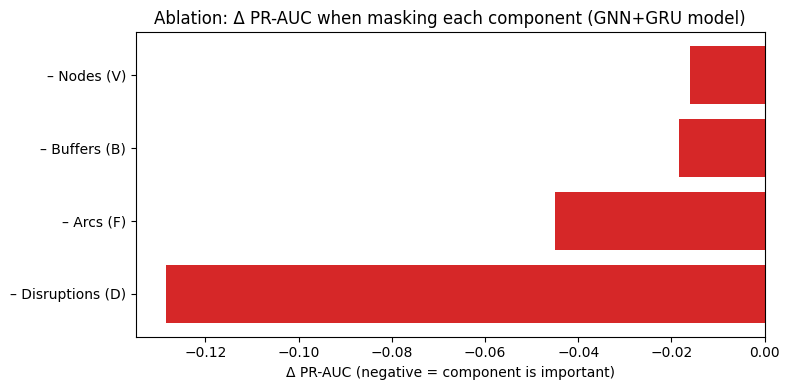

In [25]:
# 3.7 — Ablation Analysis (Section VI.C)
#
# Group ablation: mask each financial-logistics component → measure performance drop.
# ALSO: structural ablation — compare GNN+GRU vs Vanilla GRU (graph contribution).

from sklearn.metrics import roc_auc_score, average_precision_score

# ── Component ablation on GNN+GRU model ──
base_roc = roc_auc_score(yt, pt) if len(np.unique(yt))>1 else np.nan
base_pr  = average_precision_score(yt, pt) if len(np.unique(yt))>1 else np.nan

ablation_rows = [{"group": "Full Model", "n_features": len(feature_cols), "n_masked": 0,
                  "pr_auc": base_pr, "roc_auc": base_roc,
                  "delta_pr": 0.0, "delta_roc": 0.0}]

for g_name, g_idx in group_indices.items():
    print(f"  Ablating {g_name} ({len(g_idx)} features)...")
    test_ds.mask_idx = g_idx
    masked_loader = make_loader(test_ds, batch_size=BATCH_EVAL, shuffle=False)
    y_m, p_m = predict_loader(model, masked_loader)
    pr_m  = average_precision_score(y_m, p_m) if len(np.unique(y_m))>1 else np.nan
    roc_m = roc_auc_score(y_m, p_m) if len(np.unique(y_m))>1 else np.nan
    ablation_rows.append({
        "group": f"– {g_name}", "n_features": len(feature_cols) - len(g_idx),
        "n_masked": len(g_idx),
        "pr_auc": pr_m, "roc_auc": roc_m,
        "delta_pr": pr_m - base_pr if not np.isnan(pr_m) else np.nan,
        "delta_roc": roc_m - base_roc if not np.isnan(roc_m) else np.nan,
    })

test_ds.mask_idx = None
ablation_df = pd.DataFrame(ablation_rows)

print("\n══════════════════════════════════════")
print("   TABLE: ABLATION ANALYSIS")
print("══════════════════════════════════════")
display(ablation_df)

# ── Structural ablation: GNN+GRU vs Vanilla GRU ──
_, pt_v = predict_loader(best_gru_model, test_loader)
gru_roc = roc_auc_score(yt, pt_v); gru_pr = average_precision_score(yt, pt_v)
print(f"\n── Structural Ablation (Graph contribution) ──")
print(f"GNN+GRU (proposed): ROC-AUC = {base_roc:.4f}, PR-AUC = {base_pr:.4f}")
print(f"Vanilla GRU:        ROC-AUC = {gru_roc:.4f}, PR-AUC = {gru_pr:.4f}")
print(f"Graph improvement:  ΔROC = {base_roc - gru_roc:+.4f}, ΔPR = {base_pr - gru_pr:+.4f}")

# Bar chart
import matplotlib.pyplot as plt
abl_plot = ablation_df[ablation_df["group"]!="Full Model"].sort_values("delta_pr")
plt.figure(figsize=(8, 4))
colors = ["#d62728" if d < -0.005 else "#2ca02c" if d > 0.005 else "#999999"
          for d in abl_plot["delta_pr"]]
plt.barh(abl_plot["group"], abl_plot["delta_pr"], color=colors)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Ablation: Δ PR-AUC when masking each component (GNN+GRU model)")
plt.xlabel("Δ PR-AUC (negative = component is important)")
plt.tight_layout()
plt.savefig("outputs/fig_ablation_pr_auc.png", dpi=200)
plt.show()

ablation_df.to_csv("outputs/ablation_results.csv", index=False)


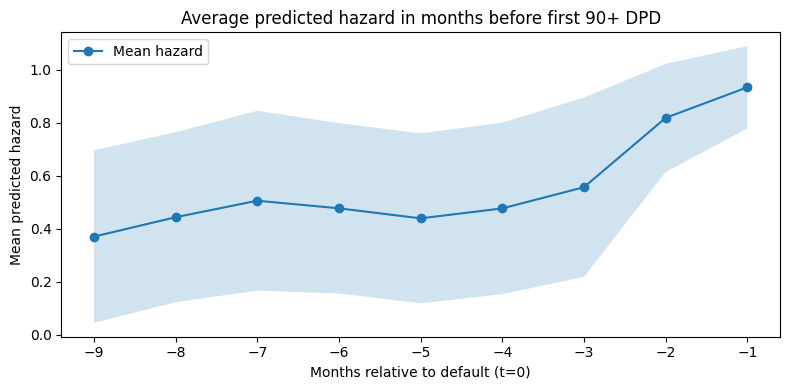

In [26]:
# 3.7b — Hazard profile before default (Figure for article)
#
# Average predicted hazard in months leading up to first 90+ DPD.

pred_df = pred_rnn.merge(default_month_tbl, on="loan_id", how="left")
pred_df["default_month_first"] = pd.to_datetime(pred_df["default_month_first"])
pred_def = pred_df.dropna(subset=["default_month_first"]).copy()

if len(pred_def) > 0:
    rel = (pred_def["month"].dt.to_period("M") - pred_def["default_month_first"].dt.to_period("M"))
    pred_def["rel_m"] = rel.apply(lambda x: x.n).astype(int)
    win = pred_def[(pred_def["rel_m"] >= -12) & (pred_def["rel_m"] <= -1)]
    curve = win.groupby("rel_m")["p_rnn"].agg(["mean","std"]).reset_index()

    plt.figure(figsize=(8, 4))
    plt.plot(curve["rel_m"], curve["mean"], marker="o", label="Mean hazard")
    plt.fill_between(curve["rel_m"],
                     curve["mean"] - curve["std"],
                     curve["mean"] + curve["std"], alpha=0.2)
    plt.title("Average predicted hazard in months before first 90+ DPD")
    plt.xlabel("Months relative to default (t=0)")
    plt.ylabel("Mean predicted hazard")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/fig_hazard_profile_before_default.png", dpi=200)
    plt.show()
else:
    print("No defaulted loans in test set — cannot compute hazard profile")


In [27]:
# 3.7c — Extended horizon evaluation (12-month forward labels)
#
# The model was trained with FORWARD_HORIZON (e.g. 6 months).
# Here we also evaluate against 12-month forward labels from the database
# to see how well the model generalizes to a longer horizon.
#
# Note: since the model outputs P(default within H months | dq_m=0),
# the one-step hazard conversion PD(12) = 1-(1-h)^12 does NOT apply.
# Instead we directly compare raw predictions against 12-month labels.

# Build 12-month labels from database
test_loan_ids = merged["loan_id"].unique().tolist()

exec_sql("DROP TABLE IF EXISTS public._tmp_test_ids;")
exec_sql("CREATE TABLE public._tmp_test_ids (loan_id text);")

from sqlalchemy import text as sa_text
with engine.begin() as conn:
    for i in range(0, len(test_loan_ids), 5000):
        batch = test_loan_ids[i:i+5000]
        values = ",".join(["('" + str(lid) + "')" for lid in batch])
        conn.execute(sa_text(f"INSERT INTO public._tmp_test_ids VALUES {values}"))

# Ensure view exists
exec_sql("""
CREATE OR REPLACE VIEW public.fm_baseline_12m AS
SELECT
  f.loan_id, f.month,
  CASE WHEN l.default_month IS NOT NULL
        AND l.default_month > f.month
        AND l.default_month <= (f.month + interval '12 months')
       THEN 1 ELSE 0 END AS y12
FROM public.fm_panel_base f
JOIN public.fm_labels l USING (loan_id);
""")

y12_df = q("""
  SELECT b.loan_id, b.month::date AS month, b.y12::int AS y12
  FROM public.fm_baseline_12m b
  JOIN public._tmp_test_ids t USING (loan_id);
""")
y12_df["month"] = pd.to_datetime(y12_df["month"])

merged12 = merged.merge(y12_df, on=["loan_id","month"], how="inner").dropna(subset=["y12"])
merged12["y12"] = merged12["y12"].astype(int)

print(f"12-month horizon evaluation set: {len(merged12):,} obs")
print(f"  12m default rate: {merged12['y12'].mean():.5f} ({int(merged12['y12'].sum()):,} events)")

# Evaluate all model predictions against 12-month labels
# (raw scores — no hazard conversion, models predict forward probability directly)
pd12_metrics = []
for col in [c for c in merged12.columns if c.startswith("p_")]:
    name = col.replace("p_", "")
    pd12_metrics.append(eval_binary(merged12["y12"].values, merged12[col].values, name))

pd12_df = pd.DataFrame(pd12_metrics)
print(f"\n=== Model performance vs 12-month forward labels ===")
print(f"    (models trained on {FORWARD_HORIZON}-month horizon,")
print(f"     evaluated on 12-month horizon)")
display(pd12_df)
pd12_df.to_csv("outputs/metrics_12m_horizon.csv", index=False)

12-month horizon evaluation set: 371,821 obs
  12m default rate: 0.00176 (654 events)

=== Model performance vs 12-month forward labels ===
    (models trained on 6-month horizon,
     evaluated on 12-month horizon)


,model,roc_auc,pr_auc,brier
0,rnn,0.91765,0.13182,0.052986
1,gru_vanilla,0.91447,0.08091,0.074533
2,Logistic Regression,0.90167,0.02320,0.136380
3,Random Forest,0.91564,0.12813,0.047116
4,Gradient Boosting,0.85873,0.11390,0.001724
5,Static NN,0.90745,0.05832,0.098459


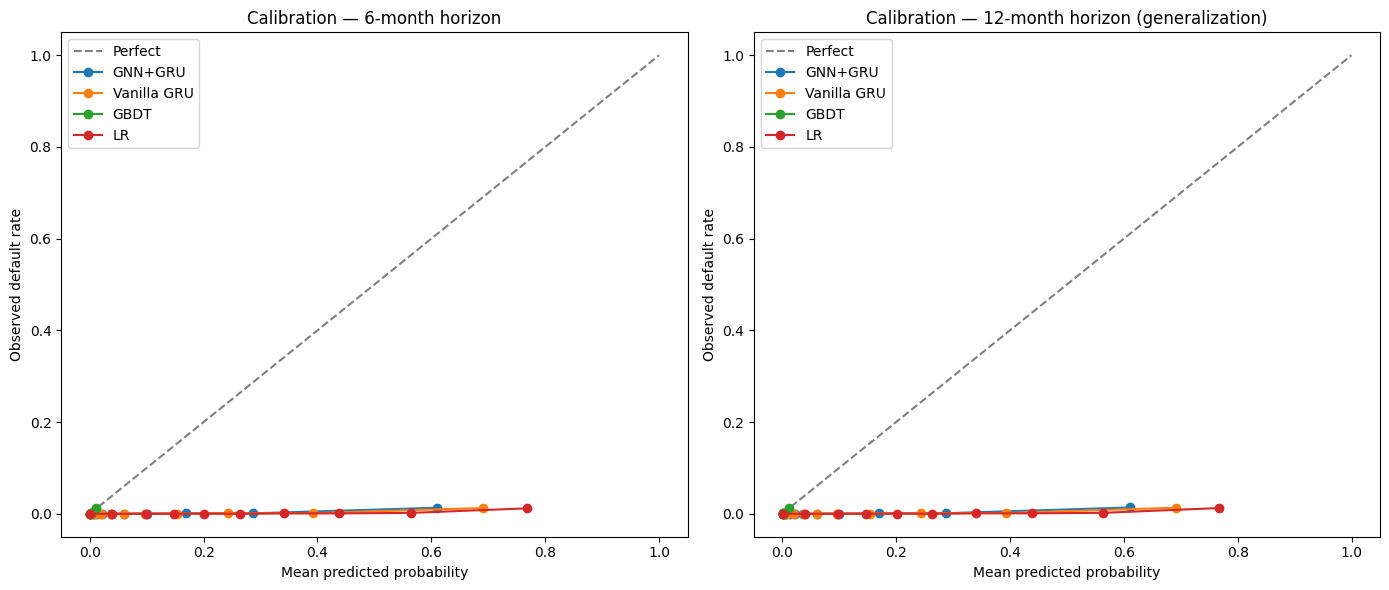

In [28]:
# 3.7d — Calibration plots
#
# Two plots:
#   1. Calibration on the training horizon (FORWARD_HORIZON months)
#   2. Calibration on 12-month horizon (generalization check)

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: Training horizon ──
ax = axes[0]
ax.plot([0,1],[0,1], "--", color="gray", label="Perfect")
cal_models_main = [
    ("GNN+GRU", "p_rnn"),
    ("Vanilla GRU", "p_gru_vanilla"),
    ("GBDT", "p_Gradient Boosting"),
    ("LR", "p_Logistic Regression"),
]
for label, col in cal_models_main:
    if col in merged.columns:
        try:
            prob_true, prob_pred = calibration_curve(
                merged["y_true"], merged[col], n_bins=10, strategy="quantile")
            ax.plot(prob_pred, prob_true, marker="o", label=label)
        except Exception as e:
            print(f"Cal failed for {label}: {e}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title(f"Calibration — {FORWARD_HORIZON}-month horizon")
ax.legend()

# ── Plot 2: 12-month horizon ──
ax = axes[1]
ax.plot([0,1],[0,1], "--", color="gray", label="Perfect")
for label, col in cal_models_main:
    if col in merged12.columns:
        try:
            prob_true, prob_pred = calibration_curve(
                merged12["y12"], merged12[col], n_bins=10, strategy="quantile")
            ax.plot(prob_pred, prob_true, marker="o", label=label)
        except Exception as e:
            print(f"Cal failed for {label}: {e}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration — 12-month horizon (generalization)")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/fig_calibration_dual.png", dpi=200)
plt.show()

In [29]:
# 3.8 — Export all results for article

all_metrics_df.to_csv("outputs/table1_comparative_metrics.csv", index=False)
lift_tbl.to_csv("outputs/table1b_lift_at_k.csv", index=False)
ablation_df.to_csv("outputs/table2_ablation.csv", index=False)
pd12_df.to_csv("outputs/metrics_pd12.csv", index=False)
gnn_df.to_csv("outputs/gnn_multiseed_results.csv", index=False)
gru_df.to_csv("outputs/gru_multiseed_results.csv", index=False)

# ── Dataset summary ──
print("══════════════════════════════════════════════")
print("   RESULTS SUMMARY FOR ARTICLE")
print("══════════════════════════════════════════════")

print(f"\nDataset: Fannie Mae CRT 2024")
print(f"  Total loan-months: {n_rows:,}")
print(f"  Unique loans: {n_loans:,}")
print(f"  Default events (90+ DPD): {n_events:,}")
print(f"  Default rate: {n_events/n_loans*100:.4f}%")
print(f"  Features: {len(feature_cols)} ({len(feat_nodes)} nodes + {len(feat_arcs)} arcs + {len(feat_bufs)} buffers + {len(feat_disr)} disruptions)")
print(f"  Sequence length: {SEQ_L} months")

print("\n── Table 1: Comparative Performance (one-step hazard) ──")
print(all_metrics_df.to_markdown(index=False))

print("\n── Multi-seed Significance ──")
print(f"GNN+GRU:     ROC = {gnn_df['roc_auc'].mean():.4f}±{gnn_df['roc_auc'].std():.4f},  PR = {gnn_df['pr_auc'].mean():.4f}±{gnn_df['pr_auc'].std():.4f}")
print(f"Vanilla GRU: ROC = {gru_df['roc_auc'].mean():.4f}±{gru_df['roc_auc'].std():.4f},  PR = {gru_df['pr_auc'].mean():.4f}±{gru_df['pr_auc'].std():.4f}")

print("\n── Lift@k ──")
print(lift_tbl.to_markdown(index=False))

print("\n── Table 2: Ablation Analysis ──")
print(ablation_df.to_markdown(index=False))

print("\n── PD(12m) horizon metrics ──")
print(pd12_df.to_markdown(index=False))

print("\n=== Output files ===")
import glob
for f in sorted(glob.glob("outputs/*")):
    print(f"  {f}")


══════════════════════════════════════════════
   RESULTS SUMMARY FOR ARTICLE
══════════════════════════════════════════════

Dataset: Fannie Mae CRT 2024
  Total loan-months: 12,059,239
  Unique loans: 756,323
  Default events (90+ DPD): 5,484
  Default rate: 0.7251%
  Features: 19 (7 nodes + 5 arcs + 3 buffers + 4 disruptions)
  Sequence length: 12 months

── Table 1: Comparative Performance (one-step hazard) ──
| model                  |   roc_auc |   pr_auc |      brier |
|:-----------------------|----------:|---------:|-----------:|
| Logistic Regression    |   0.90445 |  0.02269 |   0.136413 |
| Random Forest          |   0.92031 |  0.13083 |   0.047102 |
| Gradient Boosting      |   0.8641  |  0.11667 |   0.00162  |
| Static NN              |   0.91156 |  0.05835 |   0.09848  |
| Cox PH                 |   0.81125 |  0.0123  | nan        |
| Vanilla GRU (no graph) |   0.91821 |  0.08192 |   0.074545 |
| Proposed (GNN+GRU)     |   0.92294 |  0.13581 |   0.052979 |

── Multi-seed 